# Avito Demand Prediction: что решает судьбу объявления

Данные — соревнование Kaggle [Avito Demand Prediction Challenge](https://www.kaggle.com/c/avito-demand-prediction)
(2018): 1.5 млн объявлений за март 2017 года, 47 категорий. Предсказываем `deal_probability` —
по описанию Avito, вероятность того, что объявление приведёт к сделке. Метрика соревнования — RMSE.

Цель — не место на лидерборде, а проверяемый ответ на вопрос: **что на самом деле двигает результат —
цена, фотография или текст**. Поэтому одна модель (CatBoost) и один протокол обучения на все
эксперименты, валидация по времени и парный бутстреп для каждого сравнения: приросты здесь
в третьем-четвёртом знаке, и без доверительного интервала их не отличить от шума.

**Как устроен ноутбук.** Секции 1–13 — основной прогон на CPU; выводы вычислительных ячеек — с него.
Три тяжёлых шага считались отдельными прогонами и здесь выключены флагами — код на месте,
результат читается из файлов:

- `RUN_GPU` — эмбеддинги текста `rubert-tiny2` (GPU), секция 8;
- `RUN_IMAGES` — признаки качества по 1.4 млн фотографий (архив на десятки гигабайт), секция 9;
- `RUN_EXTRA` — срок показа в зависимости от цены (секция 11), второй заход на текст
  с дообучением энкодера (секция 14) и структурные модели (секция 15).

Графики и сводки строятся по сохранённым `results/*.json`. Короткий рассказ с итогами — в [README](README.md).

## 0. Настройка

In [1]:
import os, sys, json, time, zipfile, subprocess, gc, shutil, warnings
from pathlib import Path

import numpy as np
import pandas as pd

DATA = Path("data")
RAW  = DATA / "raw"      # CSV соревнования (качает ячейка в секции 1)
IN   = DATA / "in"       # признаки из отдельных тяжёлых прогонов (текст на GPU, фотографии)
PROC = DATA / "proc"
RES  = Path("results")   # все посчитанные числа
FIG  = Path("figures")
for d in (RAW, IN, PROC, RES, FIG):
    d.mkdir(parents=True, exist_ok=True)

# Протокол обучения. Один на все строки итоговой таблицы: строки должны
# отличаться признаками, а не настройками.
LR         = 0.1
ITERATIONS = 6000
DEPTH      = 8
OD_WAIT    = 150
N_THREADS  = os.cpu_count() or 8

CHECK_LR    = True   # один раз сравнить lr=0.1 с медленным lr=0.05 и показать разницу
DO_SURVIVAL = True   # секция 11: срок показа по periods_train.csv

# Тяжёлые шаги, которые считались отдельными прогонами. Выключены: их результат
# уже лежит в data/in (признаки) и results/ (числа).
RUN_GPU    = False   # секция 8: эмбеддинги rubert-tiny2 для 2 млн текстов
RUN_IMAGES = False   # секция 9: признаки качества по 1.4 млн фотографий
RUN_EXTRA  = False   # секции 11, 14, 15: срок показа по цене, текст v2, структурные модели

warnings.filterwarnings("ignore", message="DataFrame is highly fragmented")


def load(name):
    """Прочитать сохранённый результат из results/."""
    return json.loads((RES / f"{name}.json").read_text(encoding="utf-8"))

In [2]:
import numpy as np, pandas as pd
from catboost import CatBoostRegressor, CatBoostClassifier, Pool

print("pandas", pd.__version__, "| numpy", np.__version__)
import catboost; print("catboost", catboost.__version__)

RESULTS = {}

def save(name, obj):
    """Каждый результат ложится на диск сразу, а не в конце ноутбука."""
    def keys_to_str(o):
        if isinstance(o, dict):
            return {(k if isinstance(k, (str, int, float, bool, type(None))) else str(k)):
                    keys_to_str(v) for k, v in o.items()}
        if isinstance(o, (list, tuple)):
            return [keys_to_str(v) for v in o]
        return o
    RESULTS[name] = obj
    (RES / f"{name}.json").write_text(
        json.dumps(keys_to_str(obj), ensure_ascii=False, indent=2, default=str),
        encoding="utf-8")

pandas 2.3.3 | numpy 1.26.4
catboost 1.2.10


In [3]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, PercentFormatter

# Единый вид графиков: светлый фон, тонкие линии, приглушённая сетка.
INK, INK_2, GRID, SURFACE = "#0b0b0b", "#52514e", "#e4e3df", "#fcfcfb"
BLUE, ORANGE, RED = "#2a78d6", "#eb6834", "#e34948"
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": GRID, "axes.labelcolor": INK_2, "axes.titlecolor": INK,
    "axes.titlesize": 11.5, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.titlepad": 10, "axes.labelsize": 9.5, "xtick.color": INK_2, "ytick.color": INK_2,
    "xtick.labelsize": 9, "ytick.labelsize": 9, "axes.spines.top": False,
    "axes.spines.right": False, "axes.grid": True, "axes.axisbelow": True, "grid.color": GRID,
    "grid.linewidth": 0.6, "legend.frameon": False, "legend.fontsize": 9,
    "figure.dpi": 110, "savefig.dpi": 160, "savefig.bbox": "tight",
})


def price_axis(ax):
    """Ось «цена относительно типичной»: логарифмическая, 1 — типичная цена."""
    ax.set_xscale("log")
    ax.set_xticks([0.1, 0.25, 0.5, 1, 2, 4, 10])
    ax.xaxis.set_major_formatter(FuncFormatter(lambda v, _: f"×{v:g}"))
    ax.xaxis.set_minor_formatter(FuncFormatter(lambda *_: ""))
    ax.axvline(1, color=INK_2, lw=0.8, ls=(0, (3, 3)))
    ax.set_xlabel("цена относительно типичной для похожих товаров")

## 1. Данные

Качаем только CSV. Архивы с фотографиями (десятки гигабайт) основной части не нужны:
из них используется лишь `image_top_1`, а он уже лежит в `train.csv`.

In [4]:
# Перед скачиванием нужно принять правила соревнования на Kaggle
# и положить токен в ~/.kaggle/kaggle.json.
NEED = ["train.csv", "test.csv", "periods_train.csv"]
if RUN_EXTRA:
    NEED.append("train_active.csv")   # 9 ГБ, нужен только для срока показа по цене

for f in NEED:
    if (RAW / f).exists():
        continue
    subprocess.run(["kaggle", "competitions", "download", "-c", "avito-demand-prediction",
                    "-f", f, "-p", str(RAW)], check=True)
    z = RAW / f"{f}.zip"          # Kaggle отдаёт большие CSV упакованными
    if z.exists():
        with zipfile.ZipFile(z) as zf:
            zf.extractall(RAW)
        z.unlink()

In [5]:
LIGHT = ["item_id", "user_id", "region", "city", "parent_category_name",
         "category_name", "param_1", "param_2", "param_3", "price",
         "item_seq_number", "activation_date", "user_type", "image",
         "image_top_1", "deal_probability"]

t0 = time.time()
train = pd.read_csv(RAW / "train.csv",
                    usecols=[c for c in LIGHT],
                    parse_dates=["activation_date"])
test = pd.read_csv(RAW / "test.csv",
                   usecols=[c for c in LIGHT if c != "deal_probability"],
                   parse_dates=["activation_date"])
print(f"train {train.shape}, test {test.shape} — за {time.time()-t0:.0f}с")

train (1503424, 16), test (508438, 15) — за 14с


### Общие функции

Всё, что должно быть одинаковым во всех секциях, лежит здесь.

In [6]:
import numpy as np, pandas as pd

SEED = 42

# Границы прибиты датами, а не «последними N днями». В train.csv основное окно —
# 15..28 марта 2017 (ровно две недели, среда..вторник), но после 28 марта висит
# хвост из 100 строк, размазанный до 7 апреля. Правило «последние 3 дня в валидацию»
# отдало бы в валидацию 11 строк, и метрика считалась бы по ним. Ошибка тихая:
# ничего не падает, число выглядит правдоподобно.
TRAIN_START = pd.Timestamp("2017-03-15")
TRAIN_END   = pd.Timestamp("2017-03-21")   # неделя 1, ср..вт
VALID_START = pd.Timestamp("2017-03-22")
VALID_END   = pd.Timestamp("2017-03-28")   # неделя 2, ср..вт

CAT_COLS = ["region", "city", "parent_category_name", "category_name",
            "param_1", "param_2", "param_3", "user_type"]
NUM_COLS = ["price", "log_price", "price_is_na", "item_seq_number", "dow"]


def rmse(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.clip(np.asarray(y_pred, dtype=float), 0.0, 1.0)
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))


def time_split(df, date_col="activation_date"):
    """Неделя 1 -> обучение, неделя 2 -> валидация.

    Случайный сплит здесь завысил бы качество: у одного продавца много почти
    одинаковых объявлений, выставленных подряд, и они разъехались бы по train
    и valid. Обе недели — полные среда..вторник, чтобы разница между ними
    не оказалась разницей «будни против выходных».
    """
    d = df[date_col]
    tr = ((d >= TRAIN_START) & (d <= TRAIN_END)).to_numpy()
    va = ((d >= VALID_START) & (d <= VALID_END)).to_numpy()
    return tr, va


def last_days_split(df, days=1, date_col="activation_date"):
    """Отрезать последние `days` дат — для ранней остановки ВНУТРИ обучения."""
    dates = np.sort(df[date_col].unique())
    cutoff = dates[-days]
    tail = (df[date_col] >= cutoff).to_numpy()
    return ~tail, tail


def prepare(df):
    df = df.copy()
    df["price_is_na"] = df["price"].isna().astype(int)
    df["log_price"] = np.log1p(df["price"])
    df["dow"] = df["activation_date"].dt.dayofweek
    for c in CAT_COLS:
        if c in df.columns:
            df[c] = df[c].fillna("__na__").astype(str)
    return df


def oof_target_encode(train_keys, y, valid_keys, n_folds=5, alpha=20.0, seed=SEED):
    """На train — out-of-fold, на valid — по всему train. alpha сглаживает
    к глобальному среднему: категория с двумя объявлениями не должна получать
    своё среднее как факт."""
    rng = np.random.default_rng(seed)
    prior = float(np.mean(y)); n = len(train_keys)
    folds = rng.permutation(n) % n_folds
    tr = pd.DataFrame({"key": train_keys.to_numpy(), "y": y, "fold": folds})
    enc = np.full(n, prior)
    for f in range(n_folds):
        st = tr[tr.fold != f].groupby("key")["y"].agg(["sum", "count"])
        sm = (st["sum"] + prior * alpha) / (st["count"] + alpha)
        m = tr.fold.to_numpy() == f
        enc[m] = tr.loc[m, "key"].map(sm).fillna(prior).to_numpy()
    st = tr.groupby("key")["y"].agg(["sum", "count"])
    sm = (st["sum"] + prior * alpha) / (st["count"] + alpha)
    return enc, valid_keys.map(sm).fillna(prior).to_numpy()


def naive_target_encode(train_keys, y, valid_keys, alpha=20.0):
    """Нарочно неправильный вариант: кодируем train по нему же самому,
    вместе с самой кодируемой строкой. Нужен, чтобы показать утечку числом."""
    prior = float(np.mean(y))
    tr = pd.DataFrame({"key": train_keys.to_numpy(), "y": y})
    st = tr.groupby("key")["y"].agg(["sum", "count"])
    sm = (st["sum"] + prior * alpha) / (st["count"] + alpha)
    return (train_keys.map(sm).fillna(prior).to_numpy(),
            valid_keys.map(sm).fillna(prior).to_numpy())


def expanding_target_encode(train_keys, y, train_dates, valid_keys, alpha=20.0):
    """Кодировка, уважающая время: для строки за день d берём только дни < d.

    Обычный out-of-fold со случайными фолдами тут недостаточен: фолды случайны,
    а сплит по времени, значит строка за 18 марта получает кодировку, в которой
    участвуют строки за 19-21 марта. Формально out-of-fold, фактически из будущего.
    """
    prior = float(np.mean(y))
    d = pd.DataFrame({"key": train_keys.to_numpy(), "y": y,
                      "date": pd.to_datetime(train_dates).to_numpy()})
    enc = np.full(len(d), prior)
    for day in np.sort(d["date"].unique())[1:]:
        past = d[d.date < day]
        st = past.groupby("key")["y"].agg(["sum", "count"])
        sm = (st["sum"] + prior * alpha) / (st["count"] + alpha)
        m = (d.date == day).to_numpy()
        enc[m] = d.loc[m, "key"].map(sm).fillna(prior).to_numpy()
    st = d.groupby("key")["y"].agg(["sum", "count"])
    sm = (st["sum"] + prior * alpha) / (st["count"] + alpha)
    return enc, valid_keys.map(sm).fillna(prior).to_numpy()


def bootstrap_rmse_ci(y_true, y_pred, n_boot=400, seed=SEED):
    rng = np.random.default_rng(seed)
    e2 = (np.asarray(y_true, float) - np.clip(np.asarray(y_pred, float), 0, 1)) ** 2
    n = len(e2)
    v = np.array([np.sqrt(e2[rng.integers(0, n, n)].mean()) for _ in range(n_boot)])
    return float(np.quantile(v, .025)), float(np.quantile(v, .975))


def bootstrap_diff(y_true, pred_a, pred_b, n_boot=400, seed=SEED):
    """Парный бутстреп на одних и тех же объектах: RMSE(a) - RMSE(b).
    Отрицательное значение = a лучше."""
    rng = np.random.default_rng(seed)
    y = np.asarray(y_true, float)
    a = (y - np.clip(np.asarray(pred_a, float), 0, 1)) ** 2
    b = (y - np.clip(np.asarray(pred_b, float), 0, 1)) ** 2
    n = len(y)
    d = np.empty(n_boot)
    for i in range(n_boot):
        idx = rng.integers(0, n, n)
        d[i] = np.sqrt(a[idx].mean()) - np.sqrt(b[idx].mean())
    return float(d.mean()), float(np.quantile(d, .025)), float(np.quantile(d, .975)), float((d < 0).mean())

In [7]:
def fit_predict(tr, va, features, cat_features, y_col="deal_probability",
                monotone=None, inner_days=1, params=None, classifier=False):
    """Обучить на tr, предсказать va.

    Ранняя остановка — на последних inner_days днях ОБУЧАЮЩЕЙ части.
    Валидация в подборе числа деревьев не участвует, иначе она перестаёт
    быть честной оценкой.
    """
    inner_tr, inner_va = last_days_split(tr, days=inner_days)
    cat_idx = [features.index(c) for c in cat_features]
    p = dict(iterations=ITERATIONS, learning_rate=LR, depth=DEPTH,
             random_seed=SEED, od_type="Iter", od_wait=OD_WAIT, verbose=0,
             thread_count=N_THREADS, allow_writing_files=False)
    p["loss_function"] = "Logloss" if classifier else "RMSE"
    if params: p.update(params)
    if monotone: p["monotone_constraints"] = [monotone.get(f, 0) for f in features]

    Model = CatBoostClassifier if classifier else CatBoostRegressor
    m = Model(**p)
    m.fit(Pool(tr.loc[inner_tr, features], tr.loc[inner_tr, y_col], cat_features=cat_idx),
          eval_set=Pool(tr.loc[inner_va, features], tr.loc[inner_va, y_col],
                        cat_features=cat_idx),
          use_best_model=True)
    pool_va = Pool(va[features], cat_features=cat_idx)
    pred = m.predict_proba(pool_va)[:, 1] if classifier else m.predict(pool_va)
    return m, np.clip(pred, 0, 1)


def importances(model, features):
    return dict(zip(features, [float(v) for v in model.get_feature_importance()]))


df = prepare(train)
tr_mask, va_mask = time_split(df)
TR, VA = df[tr_mask].copy(), df[va_mask].copy()
# TEST ведём рядом с самого начала: каждый признак, который появляется у TR и VA,
# должен появиться и здесь, иначе на сабмит уедет не та модель, которую мы
# объявили лучшей, и шаг «позиция на лидерборде» будет про другое.
TEST = prepare(test)
Y_TR, Y_VA = TR["deal_probability"].to_numpy(), VA["deal_probability"].to_numpy()
print(f"обучение {len(TR):,} строк ({TRAIN_START.date()}..{TRAIN_END.date()})")
print(f"валидация {len(VA):,} строк ({VALID_START.date()}..{VALID_END.date()})")
print(f"выброшено хвостом после {VALID_END.date()}: {len(df)-len(TR)-len(VA)} строк")

LADDER = {}   # сюда копятся все строки итоговой таблицы
PREDS  = {}   # предсказания на валидации, для парных сравнений
FEATS  = {}   # какие признаки стояли за каждой строкой — понадобится для сабмита

def run(name, features, cat_features=None, **kw):
    t0 = time.time()
    cat_features = cat_features or CAT_COLS
    FEATS[name] = (list(features), list(cat_features))
    m, p = fit_predict(TR, VA, features, cat_features, **kw)
    lo, hi = bootstrap_rmse_ci(Y_VA, p)
    LADDER[name] = {"rmse": rmse(Y_VA, p), "ci95": [lo, hi],
                    "n_features": len(features),
                    "best_iteration": int(m.get_best_iteration()),
                    "minutes": round((time.time()-t0)/60, 1)}
    PREDS[name] = p
    save("ladder", LADDER)
    print(f"{name}: RMSE {LADDER[name]['rmse']:.5f}  "
          f"[{lo:.5f}, {hi:.5f}]  деревьев {LADDER[name]['best_iteration']}  "
          f"{LADDER[name]['minutes']} мин")
    return m, p

обучение 751,251 строк (2017-03-15..2017-03-21)
валидация 752,073 строк (2017-03-22..2017-03-28)
выброшено хвостом после 2017-03-28: 100 строк


## 2. Что такое `deal_probability`

Первое, что надо выяснить, — что вообще меряет таргет. Заявлено «вероятность,
что объявление привело к сделке», но у величины должны быть свойства вероятности,
и их стоит проверить, а не принять на веру.

In [8]:
from fractions import Fraction

y = train["deal_probability"].to_numpy()
n = len(y)
zeros, ones = int((y == 0).sum()), int((y == 1).sum())
mid = y[(y > 0) & (y < 1)]

# потолок считаем по каждой категории отдельно
caps = train[train.deal_probability < 1].groupby("category_name")["deal_probability"].max().round(5)
tt = train.assign(cap=train["category_name"].map(caps))
at_cap = np.isclose(tt.deal_probability, tt.cap) & (tt.deal_probability < 1)

# в услугах значения похожи на простые дроби — проверяем это отдельно
def frac_share(s, lim=20):
    v = s[(s > 0) & (s < 1)]
    if not len(v): return 0.0, 0
    hit = v.map(lambda x: abs(float(Fraction(float(x)).limit_denominator(lim)) - x) < 1e-9)
    return float(hit.mean()), int(v.nunique())

by_parent = {}
for name, g in train.groupby("parent_category_name"):
    sh, nun = frac_share(g["deal_probability"])
    by_parent[name] = {
        "n": int(len(g)),
        "доля_нулей": float((g.deal_probability == 0).mean()),
        "доля_единиц": float((g.deal_probability == 1).mean()),
        "доля_на_потолке": float(at_cap[g.index].mean()),
        "уникальных_значений": nun,
        "доля_на_простых_дробях": sh,
    }

target = {
    "n": n, "среднее": float(y.mean()),
    "rmse_константы": float(np.sqrt(((y - y.mean())**2).mean())),
    "доля_нулей": zeros/n, "доля_единиц": ones/n,
    "уникальных_значений": int(len(np.unique(y))),
    "максимум_ниже_единицы": float(mid.max()),
    "разных_потолков": int(caps.nunique()), "категорий": int(len(caps)),
    "доля_ровно_на_потолке": float(at_cap.mean()),
    "потолки": caps.to_dict(),
    "по_родительским_категориям": by_parent,
    "гистограмма": {"counts": np.histogram(y, bins=100, range=(0,1))[0].tolist()},
    "топ_значений": [{"значение": float(v), "n": int(c)}
                     for v, c in pd.Series(y).value_counts().head(30).items()],
}
save("01_target", target)

print(f"нулей {zeros/n:.1%}, единиц {ones/n:.2%}, уникальных значений {target['уникальных_значений']:,}")
print(f"RMSE константы {target['rmse_константы']:.5f}")
print(f"максимум ниже единицы {target['максимум_ниже_единицы']}, "
      f"разных потолков {target['разных_потолков']} на {target['категорий']} категорий")
print(f"ровно на потолке своей категории сидит {target['доля_ровно_на_потолке']:.2%} объявлений\n")
print(f"{'категория':<24}{'нулей':>8}{'единиц':>8}{'на потолке':>12}{'уник.знач':>11}{'простых дробей':>16}")
for k, v in sorted(by_parent.items(), key=lambda kv: -kv[1]['доля_единиц']):
    print(f"{k:<24}{v['доля_нулей']:>8.1%}{v['доля_единиц']:>8.1%}"
          f"{v['доля_на_потолке']:>12.1%}{v['уникальных_значений']:>11,}"
          f"{v['доля_на_простых_дробях']:>16.1%}")

нулей 64.8%, единиц 0.67%, уникальных значений 18,407
RMSE константы 0.26008
максимум ниже единицы 0.88059, разных потолков 13 на 47 категорий
ровно на потолке своей категории сидит 8.78% объявлений

категория                  нулей  единиц  на потолке  уник.знач  простых дробей
Услуги                     23.7%   15.6%        0.1%         21           87.9%
Недвижимость               30.9%    0.0%        0.8%      3,382            0.0%
Бытовая электроника        58.5%    0.0%       15.3%      3,962            0.0%
Для бизнеса                54.8%    0.0%        6.6%        959            0.0%
Для дома и дачи            63.1%    0.0%       13.0%      2,441            0.0%
Животные                   42.4%    0.0%       16.1%      3,425            0.0%
Личные вещи                82.6%    0.0%        6.7%      1,351            0.0%
Транспорт                  32.8%    0.0%       20.3%      3,369            0.0%
Хобби и отдых              73.3%    0.0%        9.9%      1,875            0.0%


**Вывод.** Таргет называется вероятностью, но ведёт себя иначе. 64.8% значений — ровно ноль,
у каждой категории свой потолок (13 разных на 47 категорий), и 8.8% объявлений сидят ровно на нём.
В «Услугах» 15.6% ровно единиц, а почти все значения — простые дроби. Похоже на внутреннюю оценку
Avito, обрезанную сверху по категории. Это объяснит главный источник ошибки (секция 12)
и подскажет двухчастную модель (секция 15).

## 3. Как устроен сплит соревнования

Проверяем: по времени, по пользователям или как-то ещё. И заодно — что лежит
в `periods_train.csv`, из которого по плану должен получиться второй,
независимый взгляд на ликвидность.

In [9]:
tr_u, te_u = set(train.user_id), set(test.user_id)
split = {
    "train_даты": [str(train.activation_date.min().date()), str(train.activation_date.max().date())],
    "test_даты":  [str(test.activation_date.min().date()),  str(test.activation_date.max().date())],
    "разрыв_дней": int((test.activation_date.min() - pd.Timestamp("2017-03-28")).days),
    "строк_train": len(train), "строк_test": len(test),
    "продавцов_train": len(tr_u), "продавцов_test": len(te_u),
    "продавцов_в_обоих": len(tr_u & te_u),
    "доля_тестовых_продавцов_знакомых": len(tr_u & te_u)/len(te_u),
    "доля_тестовых_строк_от_знакомых": float(test.user_id.isin(tr_u).mean()),
    "общих_объявлений": len(set(train.item_id) & set(test.item_id)),
    "строк_train_по_дням": train.groupby(train.activation_date.dt.date).size().to_dict(),
}

# periods_train: те же ли это объявления, что в train.csv?
per_ids = pd.read_csv(RAW / "periods_train.csv", usecols=["item_id"])["item_id"]
split["periods_строк"] = int(len(per_ids))
split["periods_объявлений"] = int(per_ids.nunique())
split["periods_пересечение_с_train"] = len(set(per_ids.unique()) & set(train.item_id))
del per_ids; gc.collect()

save("02_split", split)
print(f"train {split['train_даты'][0]}..{split['train_даты'][1]}, "
      f"test {split['test_даты'][0]}..{split['test_даты'][1]}, разрыв {split['разрыв_дней']} дней")
print(f"общих объявлений: {split['общих_объявлений']}")
print(f"продавцов в обоих: {split['продавцов_в_обоих']:,} — "
      f"{split['доля_тестовых_продавцов_знакомых']:.1%} тестовых, "
      f"{split['доля_тестовых_строк_от_знакомых']:.1%} тестовых строк")
print(f"\nperiods_train: {split['periods_строк']:,} строк, "
      f"{split['periods_объявлений']:,} объявлений")
print(f"пересечение periods_train с train.csv: {split['periods_пересечение_с_train']} "
      f"<- если ноль, это ДРУГИЕ объявления, и сквозной проверки таргета не выйдет")

train 2017-03-15..2017-04-07, test 2017-04-12..2017-04-20, разрыв 15 дней
общих объявлений: 0
продавцов в обоих: 67,929 — 22.2% тестовых, 30.3% тестовых строк

periods_train: 16,687,412 строк, 13,812,546 объявлений
пересечение periods_train с train.csv: 0 <- если ноль, это ДРУГИЕ объявления, и сквозной проверки таргета не выйдет


**Вывод.** Тест лежит на 15 дней позже обучения, общих объявлений нет, продавцы пересекаются частично.
Значит, валидировать надо по времени: неделя 15–21 марта — обучение, 22–28 марта — проверка,
обе ровно среда–вторник. Случайный сплит развёл бы почти одинаковые объявления одного продавца
по обучению и проверке и завысил бы качество. `periods_train` — вообще другие объявления:
это отдельная популяция, а не разметка к `train.csv`.

## 4. Выбор протокола

Быстрый протокол (lr 0.1) экономит примерно вдвое. Прежде чем считать на нём
всю таблицу, один раз сравниваем с медленным на базовой модели — чтобы решение
было подтверждено числом, а не удобством.

In [10]:
BASE_FEATS = CAT_COLS + NUM_COLS

if CHECK_LR:
    t0 = time.time()
    m_fast, p_fast = fit_predict(TR, VA, BASE_FEATS, CAT_COLS)
    t_fast = time.time() - t0
    t0 = time.time()
    m_slow, p_slow = fit_predict(TR, VA, BASE_FEATS, CAT_COLS,
                                 params=dict(learning_rate=0.05, iterations=10000,
                                             od_wait=200))
    t_slow = time.time() - t0
    d, lo, hi, share = bootstrap_diff(Y_VA, p_fast, p_slow)
    proto = {
        "быстрый_lr": LR, "быстрый_rmse": rmse(Y_VA, p_fast),
        "быстрый_деревьев": int(m_fast.get_best_iteration()), "быстрый_минут": round(t_fast/60, 1),
        "медленный_lr": 0.05, "медленный_rmse": rmse(Y_VA, p_slow),
        "медленный_деревьев": int(m_slow.get_best_iteration()), "медленный_минут": round(t_slow/60, 1),
        "разница": d, "ди95_разницы": [lo, hi], "ускорение": round(t_slow/t_fast, 1),
    }
    save("03_protocol", proto)
    print(f"lr 0.10: RMSE {proto['быстрый_rmse']:.5f}, {proto['быстрый_деревьев']} деревьев, "
          f"{proto['быстрый_минут']} мин")
    print(f"lr 0.05: RMSE {proto['медленный_rmse']:.5f}, {proto['медленный_деревьев']} деревьев, "
          f"{proto['медленный_минут']} мин")
    print(f"разница {d:+.5f}, ДИ [{lo:+.5f}, {hi:+.5f}], быстрее в {proto['ускорение']}x")
    del m_slow, p_slow; gc.collect()

lr 0.10: RMSE 0.22878, 1930 деревьев, 6.5 мин
lr 0.05: RMSE 0.22866, 5503 деревьев, 18.3 мин
разница +0.00012, ДИ [+0.00009, +0.00016], быстрее в 2.8x


**Вывод.** Медленный протокол точнее на 0.00012, и это значимо — интервал ноль не накрывает.
Но он в 2.8 раза дольше, а моделей в таблице два десятка. Берём быстрый: сравнения внутри
одного протокола честные, а абсолютные RMSE завышены примерно на эту величину. Держим в голове,
что часть эффектов ниже меньше этой поправки.

## 5. Бейзлайны

Лестница от константы до полной таблички. Проверка вменяемости: табличная модель
должна заметно бить и константу, и вариант с одними категориями. Если нет —
сломан сплит или кодирование категорий, и дальше идти нельзя.

In [11]:
const = np.full(len(VA), Y_TR.mean())
PREDS["константа"] = const
LADDER["константа"] = {"rmse": rmse(Y_VA, const), "n_features": 0,
                       "ci95": list(bootstrap_rmse_ci(Y_VA, const))}
print(f"константа: {LADDER['константа']['rmse']:.5f}")

TR["cat_reg"] = TR.category_name + " | " + TR.region
VA["cat_reg"] = VA.category_name + " | " + VA.region
for label, key in [("TE категория", "category_name"), ("TE регион", "region"),
                   ("TE категория + регион", "cat_reg")]:
    _, enc = oof_target_encode(TR[key], Y_TR, VA[key])
    PREDS[label] = enc
    LADDER[label] = {"rmse": rmse(Y_VA, enc), "n_features": 1,
                     "ci95": list(bootstrap_rmse_ci(Y_VA, enc))}
    print(f"{label}: {LADDER[label]['rmse']:.5f}")

run("CatBoost: категория + регион", ["category_name", "region"], ["category_name", "region"])
run("CatBoost: + цена", ["category_name", "region", "price", "log_price", "price_is_na"],
    ["category_name", "region"])
run("CatBoost: вся табличка", BASE_FEATS)
save("ladder", LADDER)

константа: 0.25978
TE категория: 0.24322
TE регион: 0.25961
TE категория + регион: 0.24256
CatBoost: категория + регион: RMSE 0.24319  [0.24267, 0.24368]  деревьев 1221  0.6 мин
CatBoost: + цена: RMSE 0.23746  [0.23694, 0.23795]  деревьев 1633  1.4 мин
CatBoost: вся табличка: RMSE 0.22878  [0.22825, 0.22925]  деревьев 1930  6.8 мин


In [12]:
BASE = "CatBoost: вся табличка"
checks = {}
for a, b in [(BASE, "константа"), (BASE, "TE категория + регион"),
             ("CatBoost: + цена", "CatBoost: категория + регион"),
             (BASE, "CatBoost: + цена")]:
    d, lo, hi, share = bootstrap_diff(Y_VA, PREDS[a], PREDS[b])
    checks[f"{a} vs {b}"] = {"разница": d, "ди95": [lo, hi], "доля_бутстрепов_лучше": share}
    print(f"{a} vs {b}: {d:+.5f}  ДИ [{lo:+.5f}, {hi:+.5f}]  лучше в {share:.0%}")
save("04_baselines_checks", checks)

assert LADDER[BASE]["rmse"] < LADDER["константа"]["rmse"] - 0.01, \
    "табличная модель не бьёт константу — что-то сломано, дальше идти нельзя"
print("\nпроверка вменяемости пройдена")

CatBoost: вся табличка vs константа: -0.03100  ДИ [-0.03133, -0.03068]  лучше в 100%
CatBoost: вся табличка vs TE категория + регион: -0.01378  ДИ [-0.01402, -0.01355]  лучше в 100%
CatBoost: + цена vs CatBoost: категория + регион: -0.00573  ДИ [-0.00586, -0.00561]  лучше в 100%
CatBoost: вся табличка vs CatBoost: + цена: -0.00868  ДИ [-0.00885, -0.00850]  лучше в 100%

проверка вменяемости пройдена


**Вывод.** Регион сам по себе не даёт ничего (0.25961 против 0.25978 у константы), категория —
сразу 6.4%. CatBoost на двух категориальных признаках даже чуть хуже простого группового среднего:
бустингу там нечего добавить. Выигрывать он начинает, когда появляются цена и остальная табличка.
Полная табличка — 0.22878, это база для всех следующих шагов.

## 6. Цена

Цена одновременно условие продавца и прокси качества товара. Наивная модель
может выучить «дороже → лучше продаётся», потому что дорогие вещи в среднем лучше.
Сначала показываем этот конфаундинг числом, потом строим гедонистическую модель
цены и проверяем, добавляет ли отклонение от неё что-нибудь.

In [13]:
from scipy.stats import spearmanr

ok = TR.price.notna() & (TR.price > 0)
d_ = TR[ok]
overall = float(spearmanr(d_.log_price, d_.deal_probability).statistic)
within = {}
for name, g in d_.groupby("category_name"):
    if len(g) >= 2000:
        within[name] = float(spearmanr(g.log_price, g.deal_probability).statistic)
vals = list(within.values())

conf = {
    "спирмен_по_всем_данным": overall,
    "спирмен_внутри_категорий_медиана": float(np.median(vals)),
    "доля_категорий_с_отрицательным": float(np.mean([v < 0 for v in vals])),
    "категорий_проверено": len(within),
    "по_категориям": within,
    "цена_по_родительским": {k: {q: float(g.price.quantile(q)) for q in [.05,.25,.5,.75,.95]}
                             for k, g in d_.groupby("parent_category_name")},
}
save("05_price_confounding", conf)
print(f"спирмен цены с таргетом ПО ВСЕМ ДАННЫМ:     {overall:+.4f}")
print(f"он же ВНУТРИ категорий (медиана):           {conf['спирмен_внутри_категорий_медиана']:+.4f}")
print(f"отрицательный в {conf['доля_категорий_с_отрицательным']:.0%} из {len(within)} категорий")
print("\nзнак переворачивается — это и есть конфаундинг, ради которого всё затевалось")

спирмен цены с таргетом ПО ВСЕМ ДАННЫМ:     +0.2158
он же ВНУТРИ категорий (медиана):           -0.0397
отрицательный в 65% из 43 категорий

знак переворачивается — это и есть конфаундинг, ради которого всё затевалось


In [14]:
HEDONIC = ["parent_category_name", "category_name", "param_1", "param_2",
           "param_3", "region", "city", "user_type"]

# Гедонистическую модель учим ТОЛЬКО на обучающей неделе: признак должен
# строиться одинаково и на train, и на будущем, где валидации ещё не существует.
h = TR[TR.price.notna() & (TR.price > 0)].copy()
lo_, hi_ = h.log_price.quantile([0.001, 0.999])
h = h[(h.log_price >= lo_) & (h.log_price <= hi_)]
itr, iva = last_days_split(h, days=1)
cat_idx = list(range(len(HEDONIC)))
hed = CatBoostRegressor(iterations=3000, learning_rate=0.1, depth=8, random_seed=SEED,
                        od_type="Iter", od_wait=100, verbose=0,
                        thread_count=N_THREADS, allow_writing_files=False)
hed.fit(Pool(h.loc[itr, HEDONIC], h.loc[itr, "log_price"], cat_features=cat_idx),
        eval_set=Pool(h.loc[iva, HEDONIC], h.loc[iva, "log_price"], cat_features=cat_idx),
        use_best_model=True)

yv = h.loc[iva, "log_price"].to_numpy()
pv = hed.predict(Pool(h.loc[iva, HEDONIC], cat_features=cat_idx))
r2 = 1 - float(np.mean((yv-pv)**2) / np.var(yv))

for f in (TR, VA, TEST):
    f["price_expected"] = hed.predict(Pool(f[HEDONIC], cat_features=cat_idx))
    # Где цены нет — NaN, а не ноль. Ноль означал бы «ровно как у похожих»,
    # и все такие объявления собрались бы в фальшивый пик посреди кривой.
    f["price_resid"] = f["log_price"] - f["price_expected"]

corr = float(np.corrcoef(VA.price_resid.fillna(0), VA.log_price.fillna(0))[0,1])
hstat = {"r2_на_отложенном_дне": r2, "rmse_логцены": float(np.sqrt(np.mean((yv-pv)**2))),
         "строк_обучения": int(len(h)), "деревьев": int(hed.get_best_iteration()),
         "корреляция_остатка_с_логценой": corr,
         "важности": importances(hed, HEDONIC)}
save("06_hedonic", hstat)
print(f"R2 гедонистической модели на отложенном дне: {r2:.3f}")
print(f"корреляция остатка с самим уровнем логцены:  {corr:+.3f}"
      "  (близко к 1 означало бы, что это не отклонение, а та же цена)")
print("важности:", {k: round(v,1) for k,v in sorted(hstat['важности'].items(), key=lambda kv:-kv[1])})

R2 гедонистической модели на отложенном дне: 0.825
корреляция остатка с самим уровнем логцены:  +0.372  (близко к 1 означало бы, что это не отклонение, а та же цена)
важности: {'param_1': 36.3, 'parent_category_name': 27.3, 'category_name': 10.8, 'param_2': 10.6, 'city': 4.0, 'user_type': 3.7, 'param_3': 3.7, 'region': 3.6}


In [15]:
run("+ отклонение цены", BASE_FEATS + ["price_resid"])
run("цена заменена на отклонение",
    CAT_COLS + ["price_is_na", "item_seq_number", "dow", "price_resid"])
run("+ отклонение, монотонное ограничение", BASE_FEATS + ["price_resid"],
    monotone={"price_resid": -1})

price_cmp = {}
for name in ["+ отклонение цены", "цена заменена на отклонение",
             "+ отклонение, монотонное ограничение"]:
    d, lo, hi, share = bootstrap_diff(Y_VA, PREDS[name], PREDS[BASE])
    price_cmp[f"{name} vs база"] = {"разница": d, "ди95": [lo, hi], "доля_лучше": share}
    print(f"{name}: {d:+.5f}  ДИ [{lo:+.5f}, {hi:+.5f}]")
save("07_price_models", price_cmp)

+ отклонение цены: RMSE 0.22871  [0.22818, 0.22918]  деревьев 1733  6.0 мин
цена заменена на отклонение: RMSE 0.22910  [0.22856, 0.22958]  деревьев 1557  5.6 мин
+ отклонение, монотонное ограничение: RMSE 0.22877  [0.22822, 0.22925]  деревьев 1641  5.7 мин
+ отклонение цены: -0.00008  ДИ [-0.00013, -0.00003]
цена заменена на отклонение: +0.00031  ДИ [+0.00025, +0.00037]
+ отклонение, монотонное ограничение: -0.00001  ДИ [-0.00006, +0.00005]


In [16]:
# Частичная зависимость: как факт меняется с отклонением цены.
# Только объявления с ценой — у остальных отклонения не существует.
has_price = VA.price_resid.notna().to_numpy()
r = VA.loc[has_price, "price_resid"]
bins = np.unique(np.quantile(r, np.linspace(0, 1, 21)))
idx = np.clip(np.digitize(r, bins[1:-1]), 0, len(bins)-2)
curve = []
for b in range(len(bins)-1):
    sel = np.zeros(len(VA), bool); sel[np.where(has_price)[0][idx == b]] = True
    if sel.sum() < 100: continue
    curve.append({"n": int(sel.sum()),
                  "отклонение": float(VA.loc[sel, "price_resid"].mean()),
                  "во_сколько_раз_к_типичной": float(np.expm1(VA.loc[sel,"price_resid"].mean())+1),
                  "факт": float(Y_VA[sel].mean()),
                  "модель": float(PREDS["+ отклонение цены"][sel].mean()),
                  "модель_монотонная": float(PREDS["+ отклонение, монотонное ограничение"][sel].mean())})
pd_res = {"кривая": curve,
          "без_цены": {"n": int((~has_price).sum()), "факт": float(Y_VA[~has_price].mean())},
          "оговорка": "цены никто не рандомизировал: это наблюдательная зависимость, "
                      "а не «снизь цену и получишь +X»"}
save("08_price_partial_dependence", pd_res)
print(f"{'x к типичной цене':>19}{'n':>9}{'факт':>9}{'модель':>9}")
for c in curve:
    print(f"{c['во_сколько_раз_к_типичной']:>19.2f}{c['n']:>9,}{c['факт']:>9.4f}{c['модель']:>9.4f}")
print(f"\nбез цены вообще: {pd_res['без_цены']['n']:,} объявлений, "
      f"факт {pd_res['без_цены']['факт']:.4f}")

  x к типичной цене        n     факт   модель
               0.05   35,466   0.1808   0.1821
               0.23   35,466   0.1593   0.1649
               0.33   35,466   0.1557   0.1582
               0.43   35,466   0.1497   0.1526
               0.51   35,466   0.1403   0.1482
               0.60   35,466   0.1385   0.1433
               0.69   35,450   0.1373   0.1421
               0.77   35,482   0.1420   0.1453
               0.86   35,465   0.1373   0.1429
               0.95   35,466   0.1395   0.1448
               1.06   35,467   0.1331   0.1390
               1.17   35,466   0.1319   0.1352
               1.31   35,466   0.1276   0.1307
               1.47   35,466   0.1263   0.1306
               1.68   35,466   0.1278   0.1284
               1.96   35,466   0.1225   0.1233
               2.35   35,459   0.1149   0.1206
               2.98   35,473   0.1084   0.1123
               4.27   35,466   0.1044   0.1048
              12.58   35,466   0.1013   0.1028

без цены воо

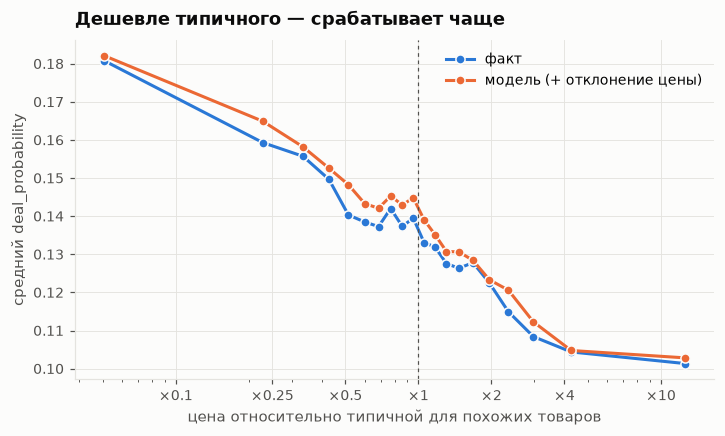

In [17]:
curve = load("08_price_partial_dependence")["кривая"]
x = [c["во_сколько_раз_к_типичной"] for c in curve]

fig, ax = plt.subplots(figsize=(7.5, 4))
for key, color, label in [("факт", BLUE, "факт"), ("модель", ORANGE, "модель (+ отклонение цены)")]:
    ax.plot(x, [c[key] for c in curve], color=color, lw=2, marker="o", ms=6,
            mec=SURFACE, mew=1, label=label)
price_axis(ax)
ax.set_ylabel("средний deal_probability")
ax.set_title("Дешевле типичного — срабатывает чаще")
ax.legend(loc="upper right")
fig.savefig(FIG / "price_curve.png")
plt.show()

**Вывод.** Конфаундинг реален: по всем данным «дороже — лучше» (Спирмен +0.216), а внутри категории
наоборот (медиана −0.040, отрицательная в 65% категорий). Дорогие категории — недвижимость, авто —
в среднем срабатывают чаще, и это перебивает то, что внутри категории дешёвое уходит быстрее.

Правильный признак — не цена, а отклонение от типичной цены похожего товара. Гедоническая модель
(приём из экономики недвижимости) объясняет 82.5% разброса логарифма цены, и её остаток даёт чистую
монотонную кривую: цена в 20 раз ниже типичной — 0.18, в 12 раз выше — 0.10.

В метрике же почти ничего: −0.00008, заменить цену остатком хуже (+0.00031), монотонное ограничение
в пределах шума. CatBoost и так вытаскивает почти всё это через категориальные статистики.
Ценность шага — в понимании, а не в приросте.

## 7. Гео и утечка через target encoding

Три степени честности одного и того же признака: наивная кодировка (среднее
по группе вместе с самой строкой), out-of-fold со случайными фолдами, и кодировка,
уважающая время (для строки за день d берём только дни раньше d).

Смотрим и на валидацию, и на обучение: наивный вариант должен выглядеть на обучении
хорошо, а на валидации плохо — это и есть утечка, увиденная числом.

In [18]:
city_stats = TR.groupby("city").agg(city_freq=("item_id","size"),
                                    city_mean_log_price=("log_price","mean"),
                                    city_n_users=("user_id","nunique"))
region_freq = TR.groupby("region").size().rename("region_freq")
for f in (TR, VA):
    for c, s in [("city_freq", city_stats.city_freq),
                 ("city_mean_log_price", city_stats.city_mean_log_price),
                 ("city_n_users", city_stats.city_n_users),
                 ("region_freq", region_freq)]:
        f[c] = f["city"].map(s) if c.startswith("city") else f["region"].map(s)
    f["city_freq"] = f.city_freq.fillna(0); f["city_n_users"] = f.city_n_users.fillna(0)
    f["region_freq"] = f.region_freq.fillna(0)
    f["city_mean_log_price"] = f.city_mean_log_price.fillna(TR.log_price.mean())
    f["price_vs_city"] = (f.log_price - f.city_mean_log_price).fillna(0)
GEO_NUM = ["city_freq","city_mean_log_price","city_n_users","region_freq","price_vs_city"]

TR["city_cat"] = TR.city + " | " + TR.category_name
VA["city_cat"] = VA.city + " | " + VA.category_name
te = {}
for key, short in [("city","city"), ("region","region"), ("city_cat","citycat")]:
    for kind, fn in [("oof", lambda: oof_target_encode(TR[key], Y_TR, VA[key])),
                     ("naive", lambda: naive_target_encode(TR[key], Y_TR, VA[key])),
                     ("time", lambda: expanding_target_encode(TR[key], Y_TR,
                                                              TR.activation_date, VA[key]))]:
        a, b = fn()
        TR[f"te_{short}_{kind}"], VA[f"te_{short}_{kind}"] = a, b
        te.setdefault(kind, []).append(f"te_{short}_{kind}")
        if short == "citycat":
            print(f"te_citycat_{kind}: корреляция с таргетом на обучении "
                  f"{np.corrcoef(a, Y_TR)[0,1]:.4f}")

te_citycat_oof: корреляция с таргетом на обучении 0.3485
te_citycat_naive: корреляция с таргетом на обучении 0.3727
te_citycat_time: корреляция с таргетом на обучении 0.3106


In [19]:
def run_geo(name, feats):
    m, p = run(name, feats)
    p_tr = np.clip(m.predict(TR[feats]), 0, 1)
    LADDER[name]["rmse_train_insample"] = rmse(Y_TR, p_tr)
    print(f"   на обучении (in-sample): {LADDER[name]['rmse_train_insample']:.5f}")
    save("ladder", LADDER)

run_geo("+ гео-признаки", BASE_FEATS + GEO_NUM)
run_geo("+ гео + TE out-of-fold", BASE_FEATS + GEO_NUM + te["oof"])
run_geo("+ гео + TE наивный", BASE_FEATS + GEO_NUM + te["naive"])
run_geo("+ гео + TE по времени", BASE_FEATS + GEO_NUM + te["time"])

geo_cmp = {}
for a, b in [("+ гео-признаки", BASE), ("+ гео + TE out-of-fold", BASE),
             ("+ гео + TE наивный", "+ гео + TE out-of-fold"),
             ("+ гео + TE по времени", "+ гео + TE out-of-fold")]:
    d, lo, hi, share = bootstrap_diff(Y_VA, PREDS[a], PREDS[b])
    geo_cmp[f"{a} vs {b}"] = {"разница": d, "ди95": [lo, hi], "доля_лучше": share}
    print(f"{a} vs {b}: {d:+.5f}  ДИ [{lo:+.5f}, {hi:+.5f}]")
save("09_geo", geo_cmp)

+ гео-признаки: RMSE 0.22868  [0.22814, 0.22916]  деревьев 1977  6.2 мин
   на обучении (in-sample): 0.22509
+ гео + TE out-of-fold: RMSE 0.22916  [0.22859, 0.22966]  деревьев 3071  9.4 мин
   на обучении (in-sample): 0.22155
+ гео + TE наивный: RMSE 0.23041  [0.22984, 0.23089]  деревьев 1616  4.9 мин
   на обучении (in-sample): 0.22309
+ гео + TE по времени: RMSE 0.22907  [0.22852, 0.22955]  деревьев 1780  5.5 мин
   на обучении (in-sample): 0.22470
+ гео-признаки vs CatBoost: вся табличка: -0.00011  ДИ [-0.00016, -0.00005]
+ гео + TE out-of-fold vs CatBoost: вся табличка: +0.00037  ДИ [+0.00030, +0.00044]
+ гео + TE наивный vs + гео + TE out-of-fold: +0.00125  ДИ [+0.00116, +0.00134]
+ гео + TE по времени vs + гео + TE out-of-fold: -0.00009  ДИ [-0.00016, -0.00002]


**Вывод.** Гео-признаки дают −0.00011 — почти ничего. Кодирование через средний таргет хуже, чем
не кодировать вовсе, в любом варианте: out-of-fold +0.00037 к базе, кодирование по времени чуть лучше
out-of-fold (−0.00009, значимо), а наивное — +0.00163 к базе, в 4.4 раза хуже честного.
CatBoost сам считает похожие статистики, упорядоченно и без утечки; ручное кодирование их дублирует
и добавляет шум.

## 8. Текст

Вопрос ровно один: добавляет ли текст что-нибудь поверх таблички, и если да —
хватает ли TF-IDF, или эмбеддинги дают сверх него.

Уровень с простыми статистиками стоит раньше TF-IDF намеренно: без него TF-IDF
припишет себе прирост от банальной длины описания.

In [20]:
def text_frame(path):
    t = pd.read_csv(path, usecols=["item_id", "title", "description"])
    t["text"] = t.title.fillna("") + " \n " + t.description.fillna("")
    letters = t.text.str.count(r"[A-Za-zА-Яа-яЁё]")
    words = t.text.str.split().str.len().fillna(0)
    s = pd.DataFrame({
        "item_id": t.item_id,
        "title_len": t.title.fillna("").str.len(),
        "desc_len": t.description.fillna("").str.len(),
        "text_words": words,
        "mean_word_len": (letters / words.replace(0, np.nan)).fillna(0),
        "upper_share": (t.text.str.count(r"[A-ZА-ЯЁ]") / letters.replace(0, np.nan)).fillna(0),
        "digit_count": t.text.str.count(r"\d"),
        "exclam": t.text.str.count("!"),
        "newlines": t.text.str.count("\n"),
        "desc_is_na": t.description.isna().astype(int),
    })
    return s, t.set_index("item_id")["text"]

stats_tr, text_map = text_frame(RAW / "train.csv")
stats_te, text_map_te = text_frame(RAW / "test.csv")
SIMPLE = [c for c in stats_tr.columns if c != "item_id"]

TR = TR.merge(stats_tr, on="item_id", how="left")
VA = VA.merge(stats_tr, on="item_id", how="left")
TEST = TEST.merge(stats_te, on="item_id", how="left")
TR_TXT = TR.item_id.map(text_map).fillna("").tolist()
VA_TXT = VA.item_id.map(text_map).fillna("").tolist()
TE_TXT = TEST.item_id.map(text_map_te).fillna("").tolist()
del stats_tr, stats_te; gc.collect()
print(f"текст готов, простых признаков {len(SIMPLE)}; "
      f"train {len(TR_TXT):,}, valid {len(VA_TXT):,}, test {len(TE_TXT):,}")

текст готов, простых признаков 9; train 751,251, valid 752,073, test 508,438


### Эмбеддинги текста (GPU, отдельный прогон)

`rubert-tiny2` (312 измерений, 29 млн параметров) по склейке заголовка и описания, обрезка до 64 токенов:
объявление начинается с сути, хвост — контакты и доставка. Вектор — среднее по токенам с учётом маски,
потом PCA до 64 компонент. На GPU это несколько минут на 2 млн текстов; готовый результат —
`data/in/text_features.npz`, его подхватывает следующая ячейка.

In [21]:
if RUN_GPU:
    import torch
    from sklearn.decomposition import PCA
    from transformers import AutoModel, AutoTokenizer

    MODEL_NAME, MAX_LEN, BATCH, N_PCA = "cointegrated/rubert-tiny2", 64, 2048, 64
    device = "cuda" if torch.cuda.is_available() else "cpu"
    tok = AutoTokenizer.from_pretrained(MODEL_NAME)
    encoder = AutoModel.from_pretrained(MODEL_NAME).to(device).eval()
    if device == "cuda":
        encoder = encoder.half()

    @torch.inference_mode()
    def embed(texts):
        out = np.empty((len(texts), encoder.config.hidden_size), dtype=np.float32)
        for i in range(0, len(texts), BATCH):
            batch = texts[i:i + BATCH]
            enc = tok(batch, padding=True, truncation=True, max_length=MAX_LEN,
                      return_tensors="pt").to(device)
            hid = encoder(**enc).last_hidden_state
            # Усреднение с учётом маски: без неё padding размывает вектор
            # коротких объявлений, а их тут много.
            mask = enc["attention_mask"].unsqueeze(-1).to(hid.dtype)
            vec = (hid * mask).sum(1) / mask.sum(1).clamp(min=1e-4)
            out[i:i + len(batch)] = vec.float().cpu().numpy()
        return out

    emb_tr, emb_te = embed(text_map.tolist()), embed(text_map_te.tolist())
    # PCA учим на окне 15–28 марта: апрельский тест не трогаем даже без таргета.
    dates = train.set_index("item_id").activation_date.reindex(text_map.index)
    fit = ((dates >= "2017-03-15") & (dates <= "2017-03-28")).to_numpy()
    pca = PCA(n_components=N_PCA, random_state=SEED).fit(emb_tr[fit])
    np.savez_compressed(
        IN / "text_features.npz",
        train=pca.transform(emb_tr).astype(np.float32),
        test=pca.transform(emb_te).astype(np.float32),
        train_ids=text_map.index.to_numpy().astype("U12"),
        test_ids=text_map_te.index.to_numpy().astype("U12"),
        explained_variance_ratio=pca.explained_variance_ratio_)
    del emb_tr, emb_te, encoder; gc.collect()

In [22]:
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer

# TF-IDF учим ТОЛЬКО на обучающей неделе: словарь, собранный по будущему, —
# та же утечка, что и target encoding по будущему.
tfidf_info, parts = {}, {"tr": [], "va": [], "te": []}
for tag, kw, ncomp in [("слова", dict(ngram_range=(1,2), max_features=100_000,
                                      min_df=5, sublinear_tf=True), 48),
                       ("символы", dict(analyzer="char_wb", ngram_range=(3,5),
                                        max_features=100_000, min_df=5,
                                        sublinear_tf=True), 32)]:
    t0 = time.time()
    vec = TfidfVectorizer(dtype=np.float32, **kw)
    Xtr = vec.fit_transform(TR_TXT)
    svd = TruncatedSVD(n_components=ncomp, random_state=SEED)
    parts["tr"].append(svd.fit_transform(Xtr))
    del Xtr; gc.collect()
    for key, texts in [("va", VA_TXT), ("te", TE_TXT)]:
        parts[key].append(svd.transform(vec.transform(texts)))
    tfidf_info[tag] = {"словарь": int(len(vec.vocabulary_)), "компонент": ncomp,
                       "объяснено_дисперсии": float(svd.explained_variance_ratio_.sum()),
                       "минут": round((time.time()-t0)/60, 1)}
    print(f"{tag}: словарь {len(vec.vocabulary_):,}, {ncomp} компонент объясняют "
          f"{svd.explained_variance_ratio_.sum():.1%}, {tfidf_info[tag]['минут']} мин")
    del vec, svd; gc.collect()

TFIDF = [f"tfidf_{i}" for i in range(sum(p.shape[1] for p in parts["tr"]))]
for frame, key in [(TR, "tr"), (VA, "va"), (TEST, "te")]:
    A = np.hstack(parts[key])
    for i, c in enumerate(TFIDF):
        frame[c] = A[:, i]
    del A
del parts; gc.collect()
save("10_tfidf", tfidf_info)

слова: словарь 100,000, 48 компонент объясняют 7.2%, 1.8 мин
символы: словарь 100,000, 32 компонент объясняют 11.1%, 8.1 мин


In [23]:
EMB = []
npz = IN / "text_features.npz"
if npz.exists():
    z = np.load(npz, allow_pickle=False)
    pos_tr = pd.Series(np.arange(len(z["train_ids"])), index=z["train_ids"])
    pos_te = pd.Series(np.arange(len(z["test_ids"])), index=z["test_ids"])
    EMB = [f"emb_{i}" for i in range(z["train"].shape[1])]
    missed = {}
    for tag, frame, src, pos in [("train", TR, "train", pos_tr),
                                 ("valid", VA, "train", pos_tr),
                                 ("test", TEST, "test", pos_te)]:
        idx = pos.reindex(frame.item_id.to_numpy()).to_numpy()
        gap = np.isnan(idx)
        missed[tag] = float(gap.mean())
        # Ненайденному объявлению ставим NaN, а не нулевой вектор: ноль — это
        # осмысленная точка в пространстве эмбеддингов, и модель приняла бы её
        # за содержательную. NaN CatBoost понимает как «значения нет».
        E = np.full((len(frame), len(EMB)), np.nan, dtype=np.float32)
        E[~gap] = z[src][idx[~gap].astype(int)]
        for i, c in enumerate(EMB):
            frame[c] = E[:, i]
        del E
    print(f"эмбеддинги подхвачены: {len(EMB)} компонент, "
          f"объяснено {float(z['explained_variance_ratio'].sum()):.1%} дисперсии")
    print("не нашлось в файле:", {k: f"{v:.1%}" for k, v in missed.items()})
    if max(missed.values()) > 0.02:
        print("ВНИМАНИЕ: пропущено больше 2% — похоже, npz посчитан "
              "по другой версии данных, проверь прежде чем верить строкам с эмбеддингами")
    del z; gc.collect()
else:
    print(f"эмбеддингов нет ({npz} не найден) — секция посчитается без них.")
    print("Это не ошибка: строки про эмбеддинги просто не появятся в таблице.")

эмбеддинги подхвачены: 64 компонент, объяснено 82.1% дисперсии
не нашлось в файле: {'train': '0.0%', 'valid': '0.0%', 'test': '0.0%'}


In [24]:
run("+ простые признаки текста", BASE_FEATS + SIMPLE)
run("+ TF-IDF", BASE_FEATS + SIMPLE + TFIDF)
if EMB:
    run("+ эмбеддинги (без TF-IDF)", BASE_FEATS + SIMPLE + EMB)
    run("+ TF-IDF и эмбеддинги", BASE_FEATS + SIMPLE + TFIDF + EMB)

text_cmp = {}
pairs = [("+ простые признаки текста", BASE), ("+ TF-IDF", "+ простые признаки текста")]
if EMB:
    pairs += [("+ эмбеддинги (без TF-IDF)", "+ простые признаки текста"),
              ("+ эмбеддинги (без TF-IDF)", "+ TF-IDF"),
              ("+ TF-IDF и эмбеддинги", "+ TF-IDF")]
for a, b in pairs:
    d, lo, hi, share = bootstrap_diff(Y_VA, PREDS[a], PREDS[b])
    text_cmp[f"{a} vs {b}"] = {"разница": d, "ди95": [lo, hi], "доля_лучше": share}
    print(f"{a} vs {b}: {d:+.5f}  ДИ [{lo:+.5f}, {hi:+.5f}]  лучше в {share:.0%}")
save("11_text", text_cmp)

+ простые признаки текста: RMSE 0.22750  [0.22698, 0.22797]  деревьев 2176  7.0 мин
+ TF-IDF: RMSE 0.22554  [0.22501, 0.22601]  деревьев 1789  5.1 мин
+ эмбеддинги (без TF-IDF): RMSE 0.22609  [0.22555, 0.22656]  деревьев 1688  4.8 мин
+ TF-IDF и эмбеддинги: RMSE 0.22519  [0.22467, 0.22566]  деревьев 1620  4.8 мин
+ простые признаки текста vs CatBoost: вся табличка: -0.00128  ДИ [-0.00137, -0.00120]  лучше в 100%
+ TF-IDF vs + простые признаки текста: -0.00196  ДИ [-0.00208, -0.00185]  лучше в 100%
+ эмбеддинги (без TF-IDF) vs + простые признаки текста: -0.00141  ДИ [-0.00153, -0.00130]  лучше в 100%
+ эмбеддинги (без TF-IDF) vs + TF-IDF: +0.00056  ДИ [+0.00044, +0.00067]  лучше в 0%
+ TF-IDF и эмбеддинги vs + TF-IDF: -0.00035  ДИ [-0.00044, -0.00027]  лучше в 100%


In [25]:
# Где текст помогает, а где нет: в одних категориях описание несёт информацию,
# в других это шаблон.
best_text = "+ TF-IDF и эмбеддинги" if EMB else "+ TF-IDF"
by_cat = {}
for name in VA.parent_category_name.unique():
    m = (VA.parent_category_name == name).to_numpy()
    if m.sum() < 500: continue
    by_cat[name] = {"n": int(m.sum()),
                    "rmse_база": rmse(Y_VA[m], PREDS[BASE][m]),
                    "rmse_с_текстом": rmse(Y_VA[m], PREDS[best_text][m]),
                    "медиана_длины_описания": float(VA.loc[m, "desc_len"].median()),
                    "доля_без_описания": float(VA.loc[m, "desc_is_na"].mean())}
    by_cat[name]["выигрыш"] = by_cat[name]["rmse_база"] - by_cat[name]["rmse_с_текстом"]
save("12_text_by_category", by_cat)
print(f"{'категория':<24}{'выигрыш':>10}{'медиана опис.':>15}{'без описания':>14}")
for k, v in sorted(by_cat.items(), key=lambda kv: -kv[1]["выигрыш"]):
    print(f"{k:<24}{v['выигрыш']:>+10.5f}{v['медиана_длины_описания']:>15.0f}"
          f"{v['доля_без_описания']:>14.0%}")

категория                  выигрыш  медиана опис.  без описания
Услуги                    +0.00921            149            0%
Животные                  +0.00750             85            6%
Для дома и дачи           +0.00613             83            7%
Личные вещи               +0.00372             66           11%
Для бизнеса               +0.00268            157            6%
Хобби и отдых             +0.00238             81            9%
Бытовая электроника       +0.00180            100            7%
Транспорт                 +0.00120            140            0%
Недвижимость              -0.00167            205            0%


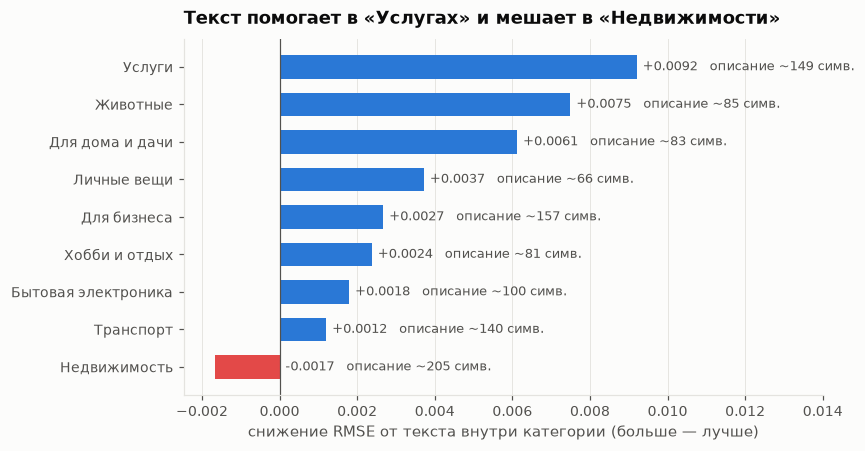

In [26]:
by_cat = load("12_text_by_category")
items = sorted(by_cat.items(), key=lambda kv: kv[1]["выигрыш"])
gain = [v["выигрыш"] for _, v in items]

fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.barh([k for k, _ in items], gain, height=0.62,
        color=[BLUE if g > 0 else RED for g in gain])
for i, (g, (_, v)) in enumerate(zip(gain, items)):
    ax.text(max(g, 0) + 0.00015, i,
            f"{g:+.4f}   описание ~{v['медиана_длины_описания']:.0f} симв.",
            va="center", fontsize=8.5, color=INK_2)
ax.axvline(0, color=INK_2, lw=0.8)
ax.grid(axis="y", visible=False)
ax.set_xlim(min(gain) - 0.0008, max(gain) + 0.0048)
ax.set_xlabel("снижение RMSE от текста внутри категории (больше — лучше)")
ax.set_title("Текст помогает в «Услугах» и мешает в «Недвижимости»")
fig.savefig(FIG / "text_by_category.png")
plt.show()

**Вывод.** Самый большой вклад текста — TF-IDF: −0.00196 поверх простых признаков. Эмбеддинги
`rubert-tiny2` вместо TF-IDF хуже (+0.00056), вместе с ним — небольшая добавка (−0.00035).
Для короткого объявления важнее, какие именно слова написаны, чем общий смысл.

И главное: вопрос «помогает ли текст» не имеет одного ответа. В «Услугах» описание — единственный
источник информации о том, что продают, и текст даёт больше всего. В «Недвижимости» он делает хуже,
хотя описания там самые длинные: они шаблонные, а всё существенное уже лежит в структурированных полях.

## 9. Картинки

`image_top_1` — готовый признак от самого Avito, код класса содержимого картинки. Он уже лежит
в табличке и не стоит ничего. Меряем его первым: если готовый признак, обученный Avito на их же данных,
даёт мало, свои признаки поверх сырых картинок вряд ли дадут заметно больше.

### Признаки качества фотографии (отдельный прогон)

Резкость (дисперсия лапласиана), яркость и контраст, цветность по Хаслеру–Зюсструнку, насыщенность,
доли пересвеченных и тёмных пикселей, размеры и вес файла. Архив `train_jpg.zip` весит десятки гигабайт,
поэтому проход по всем 1.4 млн фото делался в ядре Kaggle с примонтированными данными соревнования
(около полутора часов на CPU): архив читается напрямую, картинки декодируются сразу уменьшенными.
Результат — `data/in/image_features.parquet`, строка на фото. Тестовый архив не обрабатывался,
поэтому для сабмита эти признаки не годятся.

In [27]:
if RUN_IMAGES:
    import multiprocessing as mp
    from concurrent.futures import ProcessPoolExecutor
    from io import BytesIO
    from PIL import Image

    JPG_ZIP = RAW / "train_jpg.zip"
    SMALL, SHARD = 128, 100_000
    Image.MAX_IMAGE_PIXELS = None
    IMG_COLS = ["img_w", "img_h", "img_bytes", "img_brightness", "img_contrast",
                "img_sharpness", "img_colorfulness", "img_saturation",
                "img_dark_share", "img_blown_share", "img_is_gray"]

    def image_stats(raw):
        im = Image.open(BytesIO(raw))
        w, h = im.size                  # из заголовка, без декодирования
        # draft просит JPEG-декодер сразу отдать уменьшенную версию:
        # в разы дешевле, чем декодировать целиком и потом ресайзить
        im.draft("RGB", (SMALL, SMALL))
        a = np.asarray(im.convert("RGB"), dtype=np.float32)
        if a.size == 0:
            raise ValueError("пустая картинка")
        r, g, b = a[..., 0], a[..., 1], a[..., 2]
        gray = 0.299 * r + 0.587 * g + 0.114 * b
        lap = (gray[:-2, 1:-1] + gray[2:, 1:-1] + gray[1:-1, :-2] + gray[1:-1, 2:]
               - 4 * gray[1:-1, 1:-1]) if min(gray.shape) > 2 else np.zeros(1)
        rg, yb = r - g, 0.5 * (r + g) - b
        colorfulness = float(np.sqrt(rg.std() ** 2 + yb.std() ** 2)
                             + 0.3 * np.sqrt(rg.mean() ** 2 + yb.mean() ** 2))
        mx, mn = a.max(axis=2), a.min(axis=2)
        sat = np.where(mx > 0, (mx - mn) / np.maximum(mx, 1e-6), 0.0)
        # «Серая» — нулевая насыщенность, а не нулевой разброс rg/yb:
        # у равномерной картинки любого цвета разброс тоже нулевой.
        return (w, h, len(raw), float(gray.mean()), float(gray.std()), float(lap.var()),
                colorfulness, float(sat.mean()), float((gray < 12).mean()),
                float((gray > 243).mean()), int(float(sat.mean()) < 0.01))

    def image_worker(names):
        rows = []
        with zipfile.ZipFile(JPG_ZIP) as z:     # свой дескриптор на процесс
            for n in names:
                key = n.rsplit("/", 1)[-1][:-4]  # хеш без .jpg, как в колонке image
                try:
                    rows.append((key,) + image_stats(z.read(n)))
                except Exception:
                    rows.append((key,) + (np.nan,) * len(IMG_COLS))
        return rows

    with zipfile.ZipFile(JPG_ZIP) as z:
        names = [n for n in z.namelist() if n.lower().endswith(".jpg")]
    parts = []
    # fork: функции объявлены в ноутбуке, и при spawn дочерний процесс их не найдёт
    with ProcessPoolExecutor(N_THREADS, mp_context=mp.get_context("fork")) as ex:
        for s in range(0, len(names), SHARD):
            shard = names[s:s + SHARD]
            step = max(1, len(shard) // (N_THREADS * 4))
            chunks = [shard[i:i + step] for i in range(0, len(shard), step)]
            rows = [r for part in ex.map(image_worker, chunks) for r in part]
            parts.append(pd.DataFrame(rows, columns=["image"] + IMG_COLS))
            print(f"  {s + len(shard):,}/{len(names):,} фото", flush=True)
    pd.concat(parts, ignore_index=True).to_parquet(IN / "image_features.parquet", index=False)
    del parts; gc.collect()

In [28]:
for f in (TR, VA, TEST):
    f["has_image"] = f["image"].notna().astype(int)
    # image_top_1 — это код класса, не число: 300 не «больше» 299. Категория.
    f["image_top_1"] = f["image_top_1"].fillna(-1).astype(int).astype(str)

print(f"картинка есть у {df.image.notna().mean():.1%} объявлений, "
      f"разных image_top_1: {TR.image_top_1.nunique():,}")

run("+ есть ли картинка", BASE_FEATS + ["has_image"])
run("+ image_top_1", BASE_FEATS + ["has_image", "image_top_1"],
    CAT_COLS + ["image_top_1"])
IMG_BASE = BASE_FEATS + ["has_image", "image_top_1"]
IMG_CATS = CAT_COLS + ["image_top_1"]

# Признаки качества фотографии (ячейка выше). Если файла нет —
# секция просто заканчивается на image_top_1.
IMG_CLASSIC = []
fp = IN / "image_features.parquet"
if fp.exists():
    imf = pd.read_parquet(fp)
    IMG_CLASSIC = [c for c in imf.columns if c != "image"]
    for f in (TR, VA, TEST):
        f_new = f.merge(imf, on="image", how="left")
        for c in IMG_CLASSIC:
            f[c] = f_new[c].to_numpy()
    cover = float(TR[IMG_CLASSIC[0]].notna().mean())
    have_img = float(TR.image.notna().mean())
    print(f"классические признаки картинок подхвачены: {len(IMG_CLASSIC)} штук, "
          f"покрытие {cover:.1%} строк обучения (картинка есть у {have_img:.1%})")
    if cover < have_img - 0.05:
        print("ВНИМАНИЕ: покрытие сильно ниже доли объявлений с картинкой. "
              "Похоже, обработаны не все части архива или ключи не совпадают — "
              "строки про фотографии считать нельзя, пока это не выяснено.")
    del imf, f_new; gc.collect()

if IMG_CLASSIC:
    run("+ признаки фотографии", IMG_BASE + IMG_CLASSIC, IMG_CATS)

img_cmp = {}
pairs_img = [("+ есть ли картинка", BASE), ("+ image_top_1", "+ есть ли картинка"),
             ("+ image_top_1", BASE)]
if IMG_CLASSIC:
    pairs_img.append(("+ признаки фотографии", "+ image_top_1"))
for a, b in pairs_img:
    d, lo, hi, share = bootstrap_diff(Y_VA, PREDS[a], PREDS[b])
    img_cmp[f"{a} vs {b}"] = {"разница": d, "ди95": [lo, hi], "доля_лучше": share}
    print(f"{a} vs {b}: {d:+.5f}  ДИ [{lo:+.5f}, {hi:+.5f}]")

no_img = (VA.has_image == 0).to_numpy()
img_cmp["профиль_без_картинки"] = {
    "доля": float(no_img.mean()),
    "факт_без_картинки": float(Y_VA[no_img].mean()),
    "факт_с_картинкой": float(Y_VA[~no_img].mean()),
    "категории": VA.loc[no_img, "parent_category_name"].value_counts(normalize=True).head(5).to_dict()}
save("13_images", img_cmp)
print(f"\nбез картинки {no_img.mean():.1%}, факт у них {Y_VA[no_img].mean():.4f} "
      f"против {Y_VA[~no_img].mean():.4f}")

картинка есть у 92.5% объявлений, разных image_top_1: 3,055
+ есть ли картинка: RMSE 0.22818  [0.22763, 0.22862]  деревьев 2361  8.2 мин
+ image_top_1: RMSE 0.22496  [0.22446, 0.22543]  деревьев 2867  18.7 мин
классические признаки картинок подхвачены: 11 штук, покрытие 92.5% строк обучения (картинка есть у 92.5%)
+ признаки фотографии: RMSE 0.22449  [0.22397, 0.22496]  деревьев 2316  12.4 мин
+ есть ли картинка vs CatBoost: вся табличка: -0.00061  ДИ [-0.00067, -0.00055]
+ image_top_1 vs + есть ли картинка: -0.00322  ДИ [-0.00337, -0.00308]
+ image_top_1 vs CatBoost: вся табличка: -0.00383  ДИ [-0.00398, -0.00369]
+ признаки фотографии vs + image_top_1: -0.00046  ДИ [-0.00055, -0.00038]

без картинки 7.5%, факт у них 0.1914 против 0.1344


**Вывод.** Готовый `image_top_1` — крупнейший вклад одного признака во всём проекте: −0.00322.
Одиннадцать своих признаков качества съёмки поверх него — ещё −0.00046. Важно, *что* на фото,
а не *как* снято: «сфоткай получше» решает мало. Объявления без фото (7.5%) срабатывают даже чаще —
0.19 против 0.13, но 43% из них — недвижимость.

## 10. Насколько числу можно верить

Исходно тут планировалась проверка «предсказанные 0.3 в среднем дают факт 0.3».
На этих данных она ничего не значит: `deal_probability` не частота события,
а обрезанная оценка со шкалой, зависящей от категории (см. секцию 2).

Зато в тех же данных есть настоящее бинарное событие: `deal_probability == 0`.
У него вероятность честная, и калибровка осмысленна полностью.

In [29]:
TR["y0"] = (TR.deal_probability == 0).astype(int)
VA["y0"] = (VA.deal_probability == 0).astype(int)
print(f"доля нулей: обучение {TR.y0.mean():.4f}, валидация {VA.y0.mean():.4f}")

# Учим без последнего дня, последний день — под isotonic. Калибровочная выборка
# не должна совпадать ни с обучением, ни с валидацией.
fit_m, cal_m = last_days_split(TR, days=1)
CLF_FEATS = BASE_FEATS + ["price_resid"]
cat_idx = [CLF_FEATS.index(c) for c in CAT_COLS]
clf = CatBoostClassifier(iterations=ITERATIONS, learning_rate=LR, depth=DEPTH,
                         loss_function="Logloss", random_seed=SEED, od_type="Iter",
                         od_wait=OD_WAIT, verbose=0, thread_count=N_THREADS,
                         allow_writing_files=False)
clf.fit(Pool(TR.loc[fit_m, CLF_FEATS], TR.loc[fit_m, "y0"], cat_features=cat_idx),
        eval_set=Pool(TR.loc[cal_m, CLF_FEATS], TR.loc[cal_m, "y0"], cat_features=cat_idx),
        use_best_model=True)
p_cal = clf.predict_proba(Pool(TR.loc[cal_m, CLF_FEATS], cat_features=cat_idx))[:,1]
p_va  = clf.predict_proba(Pool(VA[CLF_FEATS], cat_features=cat_idx))[:,1]
y0 = VA.y0.to_numpy()

доля нулей: обучение 0.6482, валидация 0.6484


In [30]:
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import brier_score_loss, roc_auc_score

def reliability(y, p, nbins=20):
    edges = np.unique(np.quantile(p, np.linspace(0, 1, nbins+1)))
    idx = np.clip(np.digitize(p, edges[1:-1]), 0, len(edges)-2)
    rows, ece = [], 0.0
    for b in range(len(edges)-1):
        m = idx == b
        if not m.sum(): continue
        pred, fact = float(p[m].mean()), float(y[m].mean())
        rows.append({"n": int(m.sum()), "предсказано": pred, "факт": fact,
                     "разрыв": pred-fact})
        ece += m.mean()*abs(pred-fact)
    return rows, float(ece)

iso = IsotonicRegression(out_of_bounds="clip").fit(p_cal, TR.loc[cal_m,"y0"].to_numpy())
calib = {}
for tag, p in [("сырой", p_va), ("после isotonic", iso.predict(p_va))]:
    rows, ece = reliability(y0, p)
    calib[tag] = {"auc": float(roc_auc_score(y0, p)), "brier": float(brier_score_loss(y0, p)),
                  "ece": ece, "среднее_предсказание": float(p.mean()),
                  "средний_факт": float(y0.mean()), "кривая": rows}
    print(f"{tag:<16} AUC {calib[tag]['auc']:.4f}  Brier {calib[tag]['brier']:.5f}  "
          f"ECE {ece:.5f}  предсказано {p.mean():.4f} против факта {y0.mean():.4f}")

# порог при асимметричной цене ошибки
p_iso = iso.predict(p_va)
thr = []
for ratio in (1, 2, 3, 5, 10):
    best = min(({"cost_ratio": ratio, "порог": float(t),
                 "стоимость": int(((p_iso>=t)&(y0==0)).sum() + ratio*((p_iso<t)&(y0==1)).sum()),
                 "помечено": float((p_iso>=t).mean())}
                for t in np.linspace(0.05, 0.95, 91)), key=lambda r: r["стоимость"])
    thr.append(best)
    print(f"пропустить безнадёжное дороже в {ratio:>2}x -> порог {best['порог']:.2f}, "
          f"помечаем {best['помечено']:.1%}")
calib["пороги"] = thr

by_cat_cal = {}
for name in VA.parent_category_name.unique():
    m = (VA.parent_category_name == name).to_numpy()
    if m.sum() < 500: continue
    _, ece = reliability(y0[m], p_va[m], nbins=10)
    by_cat_cal[name] = {"n": int(m.sum()), "ece": ece,
                        "предсказано": float(p_va[m].mean()), "факт": float(y0[m].mean())}
calib["по_категориям"] = by_cat_cal
reg_rows, reg_ece = reliability(Y_VA, PREDS[BASE])
calib["надёжность_регрессии"] = {"кривая": reg_rows, "ece_подобное": reg_ece,
    "оговорка": "таргет не частота — читать как проверку несмещённости, а не как калибровку"}
save("14_calibration", calib)

сырой            AUC 0.8082  Brier 0.16468  ECE 0.00487  предсказано 0.6442 против факта 0.6484
после isotonic   AUC 0.8081  Brier 0.16477  ECE 0.00560  предсказано 0.6435 против факта 0.6484
пропустить безнадёжное дороже в  1x -> порог 0.50, помечаем 69.6%
пропустить безнадёжное дороже в  2x -> порог 0.32, помечаем 84.4%
пропустить безнадёжное дороже в  3x -> порог 0.25, помечаем 91.3%
пропустить безнадёжное дороже в  5x -> порог 0.18, помечаем 95.3%
пропустить безнадёжное дороже в 10x -> порог 0.07, помечаем 99.5%


**Вывод.** Классификатор «сработает ли вообще» откалиброван из коробки: AUC 0.808, ECE 0.005.
Изотоническая регрессия делает только хуже (ECE 0.0056) — чинить нечего. Результат отрицательный,
но полезный: такую вероятность можно сразу ставить в пороговое решение.

## 11. Второй взгляд на ликвидность: сколько объявление провисело

Важно с самого начала: это **другие** объявления, пересечение `periods_train`
с `train.csv` нулевое (проверено в секции 3). Поэтому здесь не проверка основного
таргета на тех же объектах, а сравнение двух популяций.

Данные цензурированы дважды: слева (показ начался до открытия окна 15 марта,
и когда именно — не видно) и справа (кто дожил до 28 марта, ещё не закончился).
Усечённых слева выбрасываем, цензурированных справа оставляем — иначе «средний
срок» посчитается по одним только быстро снятым.

In [31]:
if DO_SURVIVAL:
    per = pd.read_csv(RAW/"periods_train.csv",
                      parse_dates=["activation_date","date_from","date_to"])
    win_s, win_e = per.date_from.min(), per.date_to.max()
    g = per.groupby("item_id").agg(activation_date=("activation_date","min"),
                                   first_from=("date_from","min"),
                                   last_to=("date_to","max"),
                                   n_periods=("date_to","size")).reset_index()
    del per; gc.collect()
    g["right_censored"] = g.last_to >= win_e
    inside = g[g.activation_date >= win_s].copy()
    inside["duration"] = (inside.last_to - inside.activation_date).dt.days + 1
    inside["event"] = (~inside.right_censored).astype(int)
    inside = inside[inside.duration >= 1]
    print(f"окно наблюдения {win_s.date()}..{win_e.date()}")
    print(f"всего объявлений {len(g):,}, усечены слева {(g.activation_date<win_s).mean():.1%}")
    print(f"анализируем {len(inside):,}, цензурировано справа {1-inside.event.mean():.1%}")
    del g; gc.collect()

окно наблюдения 2017-03-15..2017-03-28
всего объявлений 13,812,546, усечены слева 84.6%
анализируем 2,117,190, цензурировано справа 89.1%


In [32]:
if DO_SURVIVAL:
    def kaplan_meier(duration, event):
        """S(t) = prod (1 - d_i / n_i). Реализовано руками: сетка дискретная,
        формула короткая, и видно, что происходит с цензурой."""
        o = np.argsort(duration); d, e = duration[o], event[o]
        at_risk, surv, rows = len(d), 1.0, []
        for t in np.unique(d):
            m = d == t; ev = int(e[m].sum())
            if at_risk > 0: surv *= (1 - ev/at_risk)
            rows.append({"t": int(t), "в_риске": at_risk, "снято": ev,
                         "цензура": int(m.sum())-ev, "дожили": float(surv)})
            at_risk -= int(m.sum())
        return rows

    def rmst(rows, horizon):
        """Площадь под кривой до горизонта. Медиана тут часто не достигается
        из-за цензуры, а площадь считается всегда."""
        area, pt, ps = 0.0, 0, 1.0
        for r in rows:
            if r["t"] > horizon: break
            area += ps*(r["t"]-pt); pt, ps = r["t"], r["дожили"]
        return float(area + ps*max(0, horizon-pt))

    km = kaplan_meier(inside.duration.to_numpy(), inside.event.to_numpy())
    print(f"{'дней':>5}{'дожили':>9}{'снято':>10}{'цензура':>10}")
    for r in km: print(f"{r['t']:>5}{r['дожили']:>9.3f}{r['снято']:>10,}{r['цензура']:>10,}")
    print(f"\nсредний срок показа за 14 дней: {rmst(km,14):.2f} дн.")

 дней   дожили     снято   цензура
    1    1.000         2         3
    2    0.973    57,267   124,158
    3    0.953    39,063   117,383
    4    0.937    30,847   103,381
    5    0.923    24,793   106,456
    6    0.911    19,374   116,705
    7    0.900    16,006   128,171
    8    0.891    13,238   128,374
    9    0.882    10,144   139,062
   10    0.875     7,354   134,614
   11    0.869     5,744   126,460
   12    0.864     3,961   143,399
   13    0.860     2,370   173,303
   14    0.860         0   345,558

средний срок показа за 14 дней: 12.84 дн.


### Срок показа и цена (отдельный прогон)

Главный вопрос секции — совпадает ли вывод про цену с основной задачей. Для цены и атрибутов нужен
`train_active.csv` (14 млн объявлений, 9 ГБ), поэтому эта часть считалась отдельно. Отклонение цены —
та же идея, что в секции 6: своя гедоническая модель на active-данных, потом кривые дожития
по децилям отклонения.

In [33]:
if DO_SURVIVAL and RUN_EXTRA:
    HED_COLS = ["parent_category_name", "category_name", "param_1", "param_2",
                "param_3", "region", "city", "user_type"]
    need = set(inside.item_id)
    chunks = [ch[ch.item_id.isin(need)]
              for ch in pd.read_csv(RAW / "train_active.csv",
                                    usecols=["item_id", "price"] + HED_COLS,
                                    chunksize=2_000_000)]
    life = inside.merge(pd.concat(chunks, ignore_index=True), on="item_id", how="inner")
    del chunks; gc.collect()

    d = life[life.price.notna() & (life.price > 0)].copy()
    d["log_price"] = np.log1p(d.price)
    lo_, hi_ = d.log_price.quantile([0.001, 0.999])
    fit = d[(d.log_price >= lo_) & (d.log_price <= hi_)].copy()
    for c in HED_COLS:
        fit[c] = fit[c].fillna("__na__").astype(str)
        d[c] = d[c].fillna("__na__").astype(str)
    fit = fit.sample(min(len(fit), 3_000_000), random_state=SEED)
    cat_idx = list(range(len(HED_COLS)))
    hed2 = CatBoostRegressor(iterations=1500, learning_rate=0.08, depth=8, random_seed=SEED,
                             verbose=0, thread_count=N_THREADS, allow_writing_files=False)
    hed2.fit(Pool(fit[HED_COLS], fit.log_price, cat_features=cat_idx))
    d["price_resid"] = d.log_price - hed2.predict(Pool(d[HED_COLS], cat_features=cat_idx))
    d["decile"] = pd.qcut(d.price_resid, 10, labels=False, duplicates="drop")

    by_decile = []
    for q, g in d.groupby("decile"):
        rows = kaplan_meier(g.duration.to_numpy(), g.event.to_numpy())
        by_decile.append({"дециль": int(q), "n": int(len(g)),
                          "во_сколько_раз_к_типичной": float(np.exp(g.price_resid.mean())),
                          "дней_из_14": rmst(rows, 14),
                          "снято_к_14_дню": float(1 - rows[-1]["дожили"]),
                          "доля_цензуры": float(1 - g.event.mean())})
    by_parent = {}
    for name, g in life.groupby("parent_category_name"):
        rows = kaplan_meier(g.duration.to_numpy(), g.event.to_numpy())
        by_parent[name] = {"n": int(len(g)), "дней_из_14": rmst(rows, 14),
                           "снято_к_14_дню": float(1 - rows[-1]["дожили"])}
    save("15_survival", {"окно": [str(win_s.date()), str(win_e.date())],
                         "строк": int(len(life)),
                         "цензурировано_справа": float(1 - life.event.mean()),
                         "по_децилям_цены": by_decile, "по_категориям": by_parent,
                         "оговорка": "другая популяция: пересечение с train.csv нулевое"})
    del life, d, fit; gc.collect()

 дециль  × к типичной         n  дней из 14  снято к 14-му дню
      0          0.13   202,052       12.65              15.7%
      1          0.38   202,052       12.65              15.9%
      2          0.55   202,052       12.73              15.2%
      3          0.73   202,052       12.77              14.8%
      4          0.91   202,054       12.78              14.9%
      5          1.12   202,049       12.81              14.4%
      6          1.40   202,061       12.83              14.3%
      7          1.83   202,042       12.93              13.1%
      8          2.69   202,052       13.03              12.0%
      9          7.50   202,052       13.22               9.7%

срок показа: самые дешёвые относительно типичной снимаются в 1.62 раза чаще самых дорогих
основная задача: deal_probability на краях кривой цены отличается в 1.78 раза


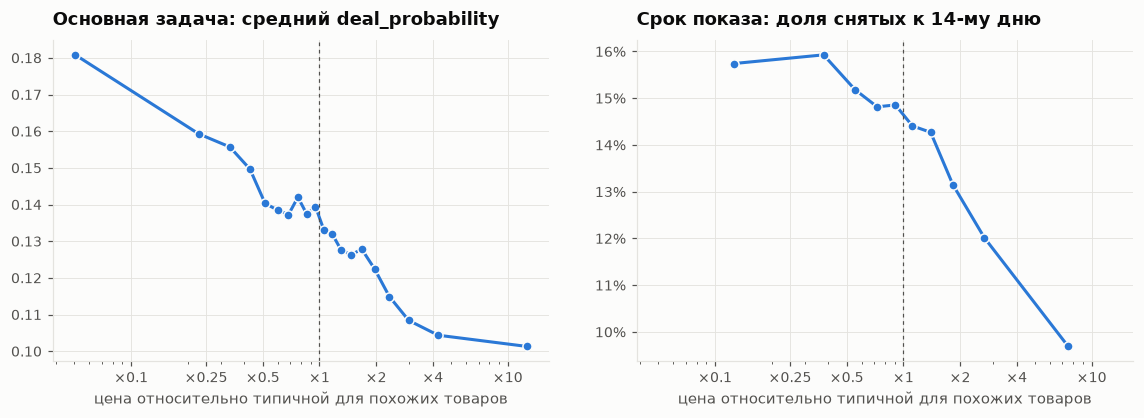

In [34]:
surv = load("15_survival")
dec = surv["по_децилям_цены"]
print(f"{'дециль':>7}{'× к типичной':>14}{'n':>10}{'дней из 14':>12}{'снято к 14-му дню':>19}")
for r in dec:
    print(f"{r['дециль']:>7}{r['во_сколько_раз_к_типичной']:>14.2f}{r['n']:>10,}"
          f"{r['дней_из_14']:>12.2f}{r['снято_к_14_дню']:>19.1%}")

curve = load("08_price_partial_dependence")["кривая"]
print(f"\nсрок показа: самые дешёвые относительно типичной снимаются в "
      f"{dec[0]['снято_к_14_дню'] / dec[-1]['снято_к_14_дню']:.2f} раза чаще самых дорогих")
print(f"основная задача: deal_probability на краях кривой цены отличается в "
      f"{curve[0]['факт'] / curve[-1]['факт']:.2f} раза")

fig, (a1, a2) = plt.subplots(1, 2, figsize=(10.5, 3.9), sharex=True)
a1.plot([c["во_сколько_раз_к_типичной"] for c in curve], [c["факт"] for c in curve],
        color=BLUE, lw=2, marker="o", ms=6, mec=SURFACE, mew=1)
a1.set_title("Основная задача: средний deal_probability")
a2.plot([r["во_сколько_раз_к_типичной"] for r in dec], [r["снято_к_14_дню"] for r in dec],
        color=BLUE, lw=2, marker="o", ms=6, mec=SURFACE, mew=1)
a2.yaxis.set_major_formatter(PercentFormatter(1, decimals=0))
a2.set_title("Срок показа: доля снятых к 14-му дню")
for ax in (a1, a2):
    price_axis(ax)
fig.tight_layout(w_pad=3)
fig.savefig(FIG / "price_two_views.png")
plt.show()

**Вывод.** За две недели снимают лишь ~14% объявлений, медиана срока показа не достигается, поэтому
считаем площадь под кривой дожития: 12.8 дня из 14. Главное — сходимость с основной задачей.
В самом дешёвом относительно типичной цены дециле к 14-му дню снято 15.7% объявлений, в самом дорогом —
9.7%, отношение 1.62; в основной задаче `deal_probability` на краях ценовой кривой отличается в 1.78 раза.
Две непересекающиеся популяции, два разных таргета, один вывод: дешевле типичного — уходит быстрее.
Это наблюдательная зависимость, а не причинная: цены никто не рандомизировал.

## 12. Разбор ошибок

Сначала систематически: где модель врёт не случайно, а по устройству задачи.
Потом конкретные объявления, выгруженные так, чтобы их можно было прочитать глазами.

In [35]:
BEST = min(LADDER, key=lambda k: LADDER[k]["rmse"])
print("лучшая модель:", BEST, f"({LADDER[BEST]['rmse']:.5f})")
pred = PREDS[BEST]
VA["pred"] = pred; VA["err"] = pred - Y_VA

VA["cap"] = VA.category_name.map(caps)
VA["группа"] = np.select(
    [VA.deal_probability == 0, VA.deal_probability == 1,
     np.isclose(VA.deal_probability, VA.cap) & (VA.deal_probability < 1)],
    ["ровно 0", "ровно 1 (только Услуги)", "ровно на потолке категории"], default="между")
VA["ценовая_группа"] = np.where(VA.price.isna(), "цены нет",
    pd.qcut(VA.price, 4, labels=["дешёвые","ниже среднего","выше среднего","дорогие"],
            duplicates="drop").astype(str))

def report(by, min_n=500):
    out = []
    for name, g in VA.groupby(by, dropna=False):
        if len(g) < min_n: continue
        out.append({"группа": str(name), "n": int(len(g)),
                    "rmse": rmse(g.deal_probability, g.pred),
                    "факт": float(g.deal_probability.mean()),
                    "предсказано": float(g.pred.mean()),
                    "смещение": float(g.pred.mean()-g.deal_probability.mean())})
    return sorted(out, key=lambda r: -r["rmse"])

err = {k: report(k) for k in ["группа","parent_category_name","ценовая_группа",
                              "user_type"]}
tot = rmse(Y_VA, pred)**2 * len(VA)
err["доля_общей_ошибки"] = {r["группа"]: round(r["n"]*r["rmse"]**2/tot, 4)
                            for r in err["группа"]}
save("16_errors", err)
for key in ["группа", "ценовая_группа"]:
    print(f"\n--- {key} ---")
    print(f"{'группа':<30}{'n':>9}{'RMSE':>9}{'факт':>9}{'предск.':>9}{'смещ.':>9}")
    for r in err[key]:
        print(f"{r['группа']:<30}{r['n']:>9,}{r['rmse']:>9.4f}{r['факт']:>9.4f}"
              f"{r['предсказано']:>9.4f}{r['смещение']:>+9.4f}")
print("\nдоля общей ошибки по группам таргета:", err["доля_общей_ошибки"])

лучшая модель: + признаки фотографии (0.22449)

--- группа ---
группа                                n     RMSE     факт  предск.    смещ.
ровно на потолке категории       65,415   0.5652   0.7994   0.2551  -0.5443
ровно 1 (только Услуги)           5,170   0.5051   1.0000   0.5177  -0.4823
между                           193,831   0.1812   0.2416   0.2033  -0.0383
ровно 0                         487,657   0.1382   0.0000   0.0995  +0.0995

--- ценовая_группа ---
группа                                n     RMSE     факт  предск.    смещ.
выше среднего                   177,223   0.2486   0.1605   0.1655  +0.0051
цены нет                         42,753   0.2426   0.2174   0.2166  -0.0008
ниже среднего                   129,923   0.2204   0.1144   0.1182  +0.0038
дорогие                         174,331   0.2166   0.1595   0.1666  +0.0071
дешёвые                         227,843   0.2089   0.1049   0.1067  +0.0018

доля общей ошибки по группам таргета: {'ровно на потолке категории': 0.5513,

In [36]:
# Худшие в обе стороны отдельно: иначе весь топ заберут единицы из Услуг
# и типология выйдет однобокой.
cols = ["item_id","deal_probability","pred","err","parent_category_name",
        "category_name","param_1","price","item_seq_number","user_type",
        "desc_len","desc_is_na","image_top_1"]
worst = pd.concat([VA.nlargest(20,"err")[cols].assign(тип="модель завысила"),
                   VA.nsmallest(20,"err")[cols].assign(тип="модель занизила")])
worst["text"] = worst.item_id.map(text_map).fillna("").str.slice(0, 300)
worst.to_csv(RES/"worst_errors.csv", index=False)
print("10 самых завышенных:")
for _, r in VA.nlargest(10,"err").iterrows():
    t = str(text_map.get(r.item_id, ""))[:60].replace("\n"," ")
    print(f"  факт {r.deal_probability:.3f} предск {r.pred:.3f} | "
          f"{r.category_name[:24]:<24} | {t}")
print("\n10 самых заниженных:")
for _, r in VA.nsmallest(10,"err").iterrows():
    t = str(text_map.get(r.item_id, ""))[:60].replace("\n"," ")
    print(f"  факт {r.deal_probability:.3f} предск {r.pred:.3f} | "
          f"{r.category_name[:24]:<24} | {t}")

10 самых завышенных:
  факт 0.000 предск 0.886 | Предложение услуг        | Аренда экскаватора JCB 3CX   Аренда / услуги Экскаватор погр
  факт 0.000 предск 0.850 | Предложение услуг        | Ремонт стиральных машин на дому   Квалифицированный вежливый
  факт 0.000 предск 0.846 | Предложение услуг        | Аренда ассенизаторской машины   Аренда ассенизаторской машин
  факт 0.000 предск 0.844 | Предложение услуг        | Экскаватор -погрузчик JCB   услуги экскаватора погрузчика :к
  факт 0.000 предск 0.836 | Предложение услуг        | Ремонт микроволновых печей   Диагностика, ремонт.
  факт 0.000 предск 0.833 | Предложение услуг        | Экскаватор погрузчик   Экскаваторы погрузчики JSB 3x, 4х. Ca
  факт 0.000 предск 0.831 | Предложение услуг        | Грузоперевозки   Доставка грузов по району и краю по доступн
  факт 0.000 предск 0.829 | Предложение услуг        | Покос травы   Покос травы, быстро и качественно!!! Курганинс
  факт 0.000 предск 0.823 | Предложение услуг        | Грузопе

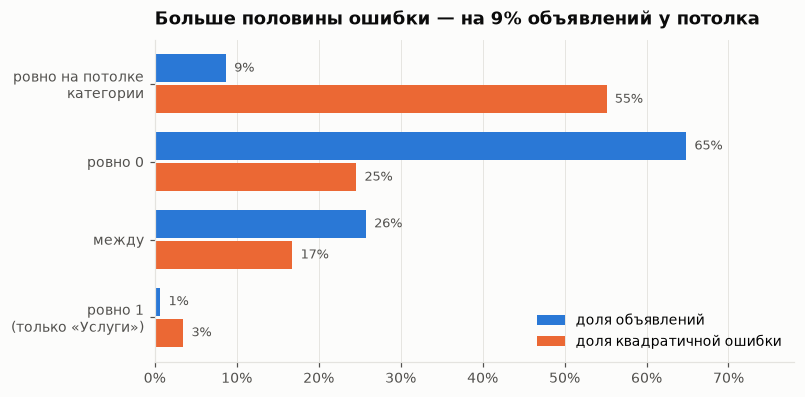

In [37]:
err = load("16_errors")
LABELS = {"ровно на потолке категории": "ровно на потолке\nкатегории", "ровно 0": "ровно 0",
          "между": "между", "ровно 1 (только Услуги)": "ровно 1\n(только «Услуги»)"}
groups = {r["группа"]: r["n"] for r in err["группа"]}
order = [g for g in LABELS if g in groups]
n_share = [groups[g] / sum(groups.values()) for g in order]
e_share = [err["доля_общей_ошибки"][g] for g in order]

y = np.arange(len(order))
fig, ax = plt.subplots(figsize=(7.5, 3.8))
for off, vals, color, label in [(-0.2, n_share, BLUE, "доля объявлений"),
                                (0.2, e_share, ORANGE, "доля квадратичной ошибки")]:
    ax.barh(y + off, vals, height=0.36, color=color, label=label)
    for yi, v in zip(y + off, vals):
        ax.text(v + 0.01, yi, f"{v:.0%}", va="center", fontsize=8.5, color=INK_2)
ax.set_yticks(y, [LABELS[g] for g in order])
ax.invert_yaxis()
ax.grid(axis="y", visible=False)
ax.xaxis.set_major_formatter(PercentFormatter(1, decimals=0))
ax.set_xlim(0, 0.78)
ax.legend(loc="lower right")
ax.set_title("Больше половины ошибки — на 9% объявлений у потолка")
fig.savefig(FIG / "error_share.png")
plt.show()

**Вывод.** 55% всей квадратичной ошибки — на 8.7% объявлений, сидящих ровно на потолке категории:
модель занижает их в среднем на 0.54. Для RMSE-модели значение 0.8 выглядит выбросом, и она тянет его
к среднему. Ещё четверть ошибки — на нулях. Худшая категория — «Услуги» (RMSE 0.319 против 0.160
у недвижимости), и конкретные промахи тоже оттуда: аренда экскаватора с фактом 0 и предсказанием 0.89,
ведущий на свадьбу с фактом 1 и предсказанием 0.1. Главный резерв — в форме таргета, а не в новых признаках.

## 13. Итоговая лестница

Лестница не накопительная: текст и фото мерились отдельно от табличной базы, чтобы честно оценить
вклад каждого. Модель «со всем сразу» — в секциях 14–15.

In [38]:
print(f"{'модель':<44}{'RMSE':>10}{'ДИ95':>22}")
for k, v in sorted(LADDER.items(), key=lambda kv: -kv[1]["rmse"]):
    ci = v.get("ci95", [float('nan')]*2)
    print(f"{k:<44}{v['rmse']:>10.5f}   [{ci[0]:.5f}, {ci[1]:.5f}]")
save("ladder", LADDER)

модель                                            RMSE                  ДИ95
константа                                      0.25978   [0.25926, 0.26034]
TE регион                                      0.25961   [0.25909, 0.26018]
TE категория                                   0.24322   [0.24270, 0.24372]
CatBoost: категория + регион                   0.24319   [0.24267, 0.24368]
TE категория + регион                          0.24256   [0.24203, 0.24304]
CatBoost: + цена                               0.23746   [0.23694, 0.23795]
+ гео + TE наивный                             0.23041   [0.22984, 0.23089]
+ гео + TE out-of-fold                         0.22916   [0.22859, 0.22966]
цена заменена на отклонение                    0.22910   [0.22856, 0.22958]
+ гео + TE по времени                          0.22907   [0.22852, 0.22955]
CatBoost: вся табличка                         0.22878   [0.22825, 0.22925]
+ отклонение, монотонное ограничение           0.22877   [0.22822, 0.22925]
+ отклонени

## 14. Второй заход на текст

Первый заход показал, что текст работает по-разному в разных категориях, а представление у него
одно на всё. Три гипотезы:

- **B.** Свой TF-IDF-словарь на каждую из 9 родительских категорий вместо общего. Почти половина
  объявлений — «Личные вещи», и слова услуг конкурируют за место в словаре с одеждой.
- **C.** Энкодер, дообученный предсказывать таргет, вместо `rubert-tiny2` из коробки.
- **D.** Не сам текст, а его отклонение от типичного для категории — тот же приём, что с ценой.

Точка отсчёта A — глобальный TF-IDF и коробочные эмбеддинги. База здесь накопительная: табличка,
простые признаки текста и `image_top_1` вместе. Ценового остатка и гео нет, протокол короче
(до 3000 деревьев), поэтому абсолютные RMSE сравниваем только между вариантами этого захода.
Считалось отдельным прогоном: дообучение энкодера — около полутора часов на GPU.

In [39]:
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer

V2_BASE = CAT_COLS + NUM_COLS + SIMPLE + ["has_image", "image_top_1"]
V2_CATS = CAT_COLS + ["image_top_1"]
V2_ITERATIONS, V2_OD_WAIT = 3000, 100
ENCODER, MAX_LEN, INFER_BATCH = "cointegrated/rubert-tiny2", 64, 512
# 24 компоненты на каждую из 9 категорий: 216 колонок, но у строки живых 24,
# остальные NaN, потому что относятся к чужим категориям.
N_CAT_SVD, N_PCA = 24, 64


def v2_device():
    import torch
    if torch.cuda.is_available():
        return "cuda"
    return "mps" if torch.backends.mps.is_available() else "cpu"


def v2_tfidf_global():
    """Один общий словарь, как в первом заходе."""
    out, info = [], {}
    for tag, kw, k in [("слова", dict(ngram_range=(1, 2), max_features=100_000,
                                      min_df=5, sublinear_tf=True), 48),
                       ("символы", dict(analyzer="char_wb", ngram_range=(3, 5),
                                        max_features=100_000, min_df=5,
                                        sublinear_tf=True), 32)]:
        vec = TfidfVectorizer(dtype=np.float32, **kw)
        svd = TruncatedSVD(n_components=k, random_state=SEED)
        svd.fit(vec.fit_transform(V2_TXT[V2_TR].tolist()))
        out.append(np.vstack([svd.transform(vec.transform(V2_TXT[i:i + 200_000].tolist()))
                              for i in range(0, len(V2_TXT), 200_000)]).astype(np.float32))
        info[tag] = {"словарь": len(vec.vocabulary_), "компонент": k,
                     "объяснено": float(svd.explained_variance_ratio_.sum())}
    save("17a_tfidf_global", info)
    return np.hstack(out)


def v2_tfidf_by_category():
    """Гипотеза B: свой словарь на каждую родительскую категорию.

    Отдельные колонки на категорию, а не общие слоты: компонента 0 у одежды
    и у услуг — разные вещи, и дерево не должно их путать. У чужой категории NaN.
    """
    cats = sorted(V2.parent_category_name.unique())
    A = np.full((len(V2), len(cats) * N_CAT_SVD), np.nan, dtype=np.float32)
    info = {}
    for j, c in enumerate(cats):
        m = (V2.parent_category_name == c).to_numpy()
        vec = TfidfVectorizer(dtype=np.float32, ngram_range=(1, 2), max_features=30_000,
                              min_df=3, sublinear_tf=True)
        X = vec.fit_transform(V2_TXT[m & V2_TR].tolist())
        k = min(N_CAT_SVD, X.shape[1] - 1, X.shape[0] - 1)
        svd = TruncatedSVD(n_components=k, random_state=SEED).fit(X)
        A[m, j * N_CAT_SVD:j * N_CAT_SVD + k] = svd.transform(vec.transform(V2_TXT[m].tolist()))
        info[c] = {"строк_обучения": int((m & V2_TR).sum()), "словарь": len(vec.vocabulary_),
                   "компонент": k, "объяснено": float(svd.explained_variance_ratio_.sum())}
    save("17b_tfidf_by_category", info)
    return A


def v2_encode(model, tok, device):
    import torch
    texts = V2_TXT.tolist()
    out = np.empty((len(texts), model.config.hidden_size), dtype=np.float32)
    with torch.no_grad():
        for i in range(0, len(texts), INFER_BATCH):
            b = tok(texts[i:i + INFER_BATCH], padding=True, truncation=True,
                    max_length=MAX_LEN, return_tensors="pt").to(device)
            h = model(**b).last_hidden_state
            mask = b["attention_mask"].unsqueeze(-1).float()
            out[i:i + INFER_BATCH] = ((h * mask).sum(1) / mask.sum(1)).cpu().numpy()
    # PCA на каждой четвёртой строке обучения: больше ему не нужно
    pca = PCA(n_components=N_PCA, random_state=SEED).fit(out[V2_TR][::4])
    return pca.transform(out).astype(np.float32)


def v2_embeddings(finetune):
    """emb0 — rubert-tiny2 из коробки; emb1 — он же, дообученный на таргете (гипотеза C).

    Дообучаем ТОЛЬКО на обучающей неделе: энкодер, увидевший таргет валидации,
    сделал бы всю дальнейшую проверку бессмысленной.
    """
    import torch
    from torch.utils.data import DataLoader, TensorDataset
    from transformers import AutoModel, AutoTokenizer

    device = v2_device()
    tok = AutoTokenizer.from_pretrained(ENCODER)
    model = AutoModel.from_pretrained(ENCODER).to(device)
    if finetune:
        torch.manual_seed(SEED)
        head = torch.nn.Linear(model.config.hidden_size, 1).to(device)
        enc = tok(V2_TXT[V2_TR].tolist(), padding="max_length", truncation=True,
                  max_length=MAX_LEN, return_tensors="pt")
        y = torch.tensor(V2.loc[V2_TR, "deal_probability"].to_numpy(), dtype=torch.float32)
        dl = DataLoader(TensorDataset(enc["input_ids"], enc["attention_mask"], y),
                        batch_size=128, shuffle=True, drop_last=True)
        opt = torch.optim.AdamW(list(model.parameters()) + list(head.parameters()), lr=3e-5)
        n_steps = len(dl) * 2
        sched = torch.optim.lr_scheduler.OneCycleLR(opt, max_lr=3e-5, total_steps=n_steps)
        model.train(); losses = []; t0 = time.time()
        for epoch in range(2):
            for ids, am, yy in dl:
                ids, am, yy = ids.to(device), am.to(device), yy.to(device)
                h = model(input_ids=ids, attention_mask=am).last_hidden_state
                mask = am.unsqueeze(-1).float()
                pooled = (h * mask).sum(1) / mask.sum(1)
                # Без clamp: за пределами [0, 1] у него нулевой градиент, и модель,
                # вылезшая за диапазон на старте, перестала бы учиться на этих строках.
                loss = torch.nn.functional.mse_loss(head(pooled).squeeze(-1), yy)
                loss.backward(); opt.step(); sched.step(); opt.zero_grad()
                losses.append(float(loss))
        save("17c_finetune", {"минут_обучения": round((time.time() - t0) / 60, 1),
                              "шагов": n_steps, "loss_в_конце": float(np.mean(losses[-500:])),
                              "дисперсия_таргета": float(V2.loc[V2_TR, "deal_probability"].var())})
        del enc, dl
    model.eval()
    return v2_encode(model, tok, device)


def v2_text_resid(tfidf):
    """Гипотеза D: отклонение текста от среднего по категории (20 старших компонент).
    Среднее — по обучающей неделе: на валидации его знать неоткуда."""
    T = tfidf[:, :20]
    R = np.empty_like(T)
    cat = V2.parent_category_name.to_numpy()
    for c in np.unique(cat):
        m = cat == c
        R[m] = T[m] - T[m & V2_TR].mean(axis=0)
    return R.astype(np.float32)


def v2_inner_split(mask):
    """Ранняя остановка по последнему дню обучающей части; валидацию модель не видит."""
    last = V2.loc[mask, "activation_date"].max()
    iva = (V2.activation_date == last).to_numpy() & mask
    return mask & ~iva, iva


def v2_matrix(keys, mask_cats=()):
    """Табличка + текстовые блоки. mask_cats — где заглушить текст (NaN = «значения нет»)."""
    cols = {c: V2[c].to_numpy() for c in V2_BASE}
    bad = V2.parent_category_name.isin(mask_cats).to_numpy()
    for k in keys:
        A = BLOCKS[k].copy() if bad.any() else BLOCKS[k]
        A[bad] = np.nan
        for i in range(A.shape[1]):
            cols[f"{k}_{i}"] = A[:, i]
    X = pd.DataFrame(cols)
    return X, [X.columns.get_loc(c) for c in V2_CATS]


def v2_fit(X, y, cat_idx, itr, iva, classifier=False):
    Model = CatBoostClassifier if classifier else CatBoostRegressor
    m = Model(iterations=V2_ITERATIONS, learning_rate=LR, depth=DEPTH, random_seed=SEED,
              od_type="Iter", od_wait=V2_OD_WAIT, verbose=0, thread_count=N_THREADS,
              allow_writing_files=False,
              loss_function="Logloss" if classifier else "RMSE")
    m.fit(Pool(X[itr], y[itr], cat_features=cat_idx),
          eval_set=Pool(X[iva], y[iva], cat_features=cat_idx), use_best_model=True)
    return m

In [40]:
V2_VARIANTS = {
    "A": ("A. глобальный TF-IDF + эмбеддинги из коробки", ["tfidf", "emb0"]),
    "B": ("B. TF-IDF по категориям вместо глобального", ["cattf", "emb0"]),
    "C": ("C. дообученный энкодер вместо коробочного", ["tfidf", "emb1"]),
    "D": ("D. + отклонение текста от категории", ["tfidf", "emb0", "resid"]),
    "B2": ("B2. глобальный и по категориям вместе", ["tfidf", "cattf", "emb0"]),
    "E": ("E. всё лучшее вместе", ["tfidf", "cattf", "emb1", "resid"]),
}

if RUN_EXTRA:
    # База этого и следующего захода: строки TR и VA в исходном порядке.
    cols = V2_BASE + ["item_id", "activation_date", "deal_probability"]
    V2 = pd.concat([TR[cols], VA[cols]], ignore_index=True)
    V2["is_valid"] = np.r_[np.zeros(len(TR), int), np.ones(len(VA), int)]
    V2_TXT = pd.Series(TR_TXT + VA_TXT)
    V2_TR, V2_VA = (V2.is_valid == 0).to_numpy(), (V2.is_valid == 1).to_numpy()
    V2_Y = V2.deal_probability.to_numpy()

    BLOCKS = {"tfidf": v2_tfidf_global(), "cattf": v2_tfidf_by_category(),
              "emb0": v2_embeddings(finetune=False), "emb1": v2_embeddings(finetune=True)}
    BLOCKS["resid"] = v2_text_resid(BLOCKS["tfidf"])

    V2_PREDS, v2_res = {}, {}
    itr, iva = v2_inner_split(V2_TR)
    for key, (name, blocks) in V2_VARIANTS.items():
        t0 = time.time()
        X, cat_idx = v2_matrix(blocks)
        m = v2_fit(X, V2_Y, cat_idx, itr, iva)
        V2_PREDS[key] = np.clip(m.predict(Pool(X[V2_VA], cat_features=cat_idx)), 0, 1)
        v2_res[name] = {"rmse": rmse(V2_Y[V2_VA], V2_PREDS[key]), "признаков": X.shape[1],
                        "блоки": blocks, "деревьев": int(m.get_best_iteration()),
                        "минут": round((time.time() - t0) / 60, 1)}
        del X, m; gc.collect()
    save("17_text_v2", v2_res)

    y_va = V2_Y[V2_VA]
    diffs, overall = {}, {}
    for key, (name, _) in V2_VARIANTS.items():
        if key == "A":
            continue
        d, lo, hi, share = bootstrap_diff(y_va, V2_PREDS[key], V2_PREDS["A"])
        diffs[f"{name} vs A"] = {"разница": d, "ди95": [lo, hi], "доля_лучше": share}
        overall[key] = {"rmse": rmse(y_va, V2_PREDS[key]), "против_A": d, "ди95": [lo, hi]}
    save("17_text_v2_diffs", diffs)

    # где именно поменялось: общий RMSE не отвечает на вопрос «где»
    best = min(overall, key=lambda k: overall[k]["rmse"])
    cat = V2.loc[V2_VA, "parent_category_name"].to_numpy()
    dlen = V2.loc[V2_VA, "desc_len"].to_numpy()
    by_cat = {}
    for c in sorted(set(cat)):
        m = cat == c
        ra, rb = rmse(y_va[m], V2_PREDS["A"][m]), rmse(y_va[m], V2_PREDS[best][m])
        by_cat[c] = {"n": int(m.sum()), "rmse_A": ra, f"rmse_{best}": rb, "выигрыш": ra - rb,
                     "медиана_описания": float(np.median(dlen[m]))}
    save("17_text_v2_by_category", {"общее": overall, "лучший": best, "по_категориям": by_cat})

In [41]:
v2, v2d, v2c = load("17_text_v2"), load("17_text_v2_diffs"), load("17_text_v2_by_category")
print(f"{'вариант':<46}{'RMSE':>9}{'против A':>11}{'ДИ95':>24}")
for name, r in v2.items():
    c = v2d.get(f"{name} vs A")
    tail = f"{c['разница']:>+11.5f}   [{c['ди95'][0]:+.5f}, {c['ди95'][1]:+.5f}]" if c else ""
    print(f"{name:<46}{r['rmse']:>9.5f}{tail}")

ft = load("17c_finetune")
print(f"\nдообучение энкодера: {ft['шагов']:,} шагов, {ft['минут_обучения']:.0f} мин; MSE на обучении "
      f"{ft['loss_в_конце']:.4f} при дисперсии таргета {ft['дисперсия_таргета']:.4f}")

print(f"\nгде выиграл вариант {v2c['лучший']} (против A):")
print(f"{'категория':<24}{'выигрыш':>10}{'медиана описания':>18}")
for k, v in sorted(v2c["по_категориям"].items(), key=lambda kv: -kv[1]["выигрыш"]):
    print(f"{k:<24}{v['выигрыш']:>+10.5f}{v['медиана_описания']:>18.0f}")

вариант                                            RMSE   против A                    ДИ95
A. глобальный TF-IDF + эмбеддинги из коробки    0.22321
B. TF-IDF по категориям вместо глобального      0.22301   -0.00020   [-0.00030, -0.00009]
C. дообученный энкодер вместо коробочного       0.22305   -0.00016   [-0.00028, -0.00002]
D. + отклонение текста от категории             0.22317   -0.00004   [-0.00012, +0.00003]
B2. глобальный и по категориям вместе           0.22297   -0.00024   [-0.00033, -0.00016]
E. всё лучшее вместе                            0.22278   -0.00042   [-0.00055, -0.00028]

дообучение энкодера: 11,738 шагов, 93 мин; MSE на обучении 0.0542 при дисперсии таргета 0.0678

где выиграл вариант E (против A):
категория                  выигрыш  медиана описания
Животные                  +0.00324                85
Услуги                    +0.00203               149
Для дома и дачи           +0.00035                83
Транспорт                 +0.00032               140
Хобби и

**Вывод.** Все три идеи вместе (E) дают −0.00042 — значимо, но по общему числу это крохи.
Дообучение энкодера (полтора часа счёта) дало −0.00016 и себя не окупило: TF-IDF с категорией и ценой
уже вычерпывают текстовый сигнал. Отклонение от категории — ноль.

Зато разбивка по категориям повторяет первый заход, на других признаках: «Животные» и «Услуги» в плюсе,
«Недвижимость» и «Для бизнеса» — в минусе. И дело не в длине: у животных описания самые короткие,
у недвижимости — самые длинные. Единая обработка текста для всех категорий — тупик: в одних
она помогает, в других вредит, и в сумме выходит почти ноль.

## 15. Третий заход: структура таргета вместо признаков

Раз 55% ошибки сидит на потолках, бить надо в форму таргета. Точка отсчёта — лучшая модель
второго захода E, признаки те же; меняется только, *что* и *как* предсказываем:

- **диагностика**: отличимы ли объявления у потолка заранее (классификатор на одной табличке);
- **двухчастная модель**: P(y > 0) × E[y | y > 0] — прямое следствие того, что таргет двухмеханизменный;
- **нормировка на потолок**: учим y / cap категории, возвращаем × cap;
- **текст по маске**: глушим текст в «Недвижимости» и «Для бизнеса», где он вредил.

In [42]:
TEXT_BAD_CATS = ["Недвижимость", "Для бизнеса"]


def v3_report(name, pred, extra=None):
    y_va, base = V2_Y[V2_VA], V2_PREDS["E"]
    d, lo, hi, share = bootstrap_diff(y_va, pred, base)
    cat = V2.loc[V2_VA, "parent_category_name"].to_numpy()
    by = {}
    for c in sorted(set(cat)):
        m = cat == c
        by[c] = {"n": int(m.sum()), "rmse_E": rmse(y_va[m], base[m]),
                 "rmse_ход": rmse(y_va[m], pred[m]),
                 "выигрыш": rmse(y_va[m], base[m]) - rmse(y_va[m], pred[m])}
    save(f"18_{name}", {"rmse": rmse(y_va, pred), "baseline_E": rmse(y_va, base),
                        "против_E": d, "ди95": [lo, hi], "доля_лучше": share,
                        **(extra or {}), "по_категориям": by})


if RUN_EXTRA:
    from sklearn.metrics import roc_auc_score
    itr, iva = v2_inner_split(V2_TR)
    cap = V2.loc[V2_TR].groupby("category_name").deal_probability.max()
    cap_row = V2.category_name.map(cap).fillna(float(cap.max())).to_numpy()

    # 1. Диагностика: отличимы ли объявления у потолка, по одной табличке
    near = ((V2_Y >= 0.9 * cap_row) & (V2_Y > 0)).astype(int)
    Xb = V2[V2_BASE]
    clf = v2_fit(Xb, near, [V2_BASE.index(c) for c in V2_CATS], itr, iva, classifier=True)
    p = clf.predict_proba(Pool(Xb[V2_VA], cat_features=[V2_BASE.index(c) for c in V2_CATS]))[:, 1]
    top = np.argsort(p)[-int(0.1 * V2_VA.sum()):]
    save("18_ceiling_classifier", {"auc": float(roc_auc_score(near[V2_VA], p)),
                                   "точность_топ10": float(near[V2_VA][top].mean()),
                                   "базовая_доля": float(near[V2_VA].mean())})

    X, cat_idx = v2_matrix(V2_VARIANTS["E"][1])
    pool_va = Pool(X[V2_VA], cat_features=cat_idx)

    # 2. Двухчастная модель: «сработает ли вообще» × «насколько, если сработает»
    clf = v2_fit(X, (V2_Y > 0).astype(int), cat_idx, itr, iva, classifier=True)
    p_pos = clf.predict_proba(pool_va)[:, 1]
    itr2, iva2 = v2_inner_split(V2_TR & (V2_Y > 0))
    e_pos = np.clip(v2_fit(X, V2_Y, cat_idx, itr2, iva2).predict(pool_va), 0, 1)
    v3_report("hurdle", np.clip(p_pos * e_pos, 0, 1),
              {"auc_класса_y>0": float(roc_auc_score((V2_Y[V2_VA] > 0).astype(int), p_pos))})

    # 3. Нормировка на потолок категории
    cap_n = np.clip(cap_row, 0.05, 1.0)
    frac = v2_fit(X, V2_Y / cap_n, cat_idx, itr, iva).predict(pool_va)
    v3_report("capnorm", np.clip(frac * cap_n[V2_VA], 0, 1))
    del X; gc.collect()

    # 4. Текст по маске: NaN в категориях, где текст вредил
    X, cat_idx = v2_matrix(V2_VARIANTS["E"][1], mask_cats=TEXT_BAD_CATS)
    m = v2_fit(X, V2_Y, cat_idx, itr, iva)
    v3_report("textmask", np.clip(m.predict(Pool(X[V2_VA], cat_features=cat_idx)), 0, 1))
    del X, m; gc.collect()

In [43]:
hc = load("18_ceiling_classifier")
print(f"диагностика потолка (одна табличка): AUC {hc['auc']:.3f}; среди топ-10% кандидатов "
      f"у потолка {hc['точность_топ10']:.0%} при базовой доле {hc['базовая_доля']:.0%}\n")

moves = {k: load(f"18_{k}") for k in ["hurdle", "capnorm", "textmask"]}
titles = {"hurdle": "двухчастная модель", "capnorm": "нормировка на потолок",
          "textmask": "текст по маске"}
print(f"{'ход':<26}{'RMSE':>9}{'против E':>11}{'ДИ95':>24}")
print(f"{'E, точка отсчёта':<26}{moves['hurdle']['baseline_E']:>9.5f}")
for k, r in moves.items():
    print(f"{titles[k]:<26}{r['rmse']:>9.5f}{r['против_E']:>+11.5f}   "
          f"[{r['ди95'][0]:+.5f}, {r['ди95'][1]:+.5f}]")

print("\nдвухчастная модель по категориям (снижение RMSE против E):")
for k, v in sorted(moves["hurdle"]["по_категориям"].items(), key=lambda kv: -kv[1]["выигрыш"]):
    print(f"  {k:<24}{v['выигрыш']:>+9.5f}")

диагностика потолка (одна табличка): AUC 0.824; среди топ-10% кандидатов у потолка 39% при базовой доле 10%

ход                            RMSE   против E                    ДИ95
E, точка отсчёта            0.22278
двухчастная модель          0.22254   -0.00024   [-0.00034, -0.00015]
нормировка на потолок       0.22277   -0.00002   [-0.00010, +0.00007]
текст по маске              0.22277   -0.00002   [-0.00010, +0.00007]

двухчастная модель по категориям (снижение RMSE против E):
  Для бизнеса              +0.00116
  Недвижимость             +0.00106
  Услуги                   +0.00079
  Транспорт                +0.00053
  Хобби и отдых            +0.00030
  Личные вещи              +0.00017
  Для дома и дачи          +0.00014
  Бытовая электроника      -0.00014
  Животные                 -0.00046


**Вывод.** Объявления у потолка отличимы заранее: AUC 0.82, а среди топ-10% кандидатов у потолка
реально 39% против базовых 10%. Значит, занижение — отчасти осторожность RMSE-модели, и резерв есть.

Сработала двухчастная модель: −0.00024, интервал ноль не накрывает. Больше всего она помогает
в «Для бизнеса», «Недвижимости» и «Услугах» — там, где сделок много и разделение «сработает ли» /
«насколько» информативно (и ровно там, где текст вредил). Нормировка на потолок дала ноль: потолки
категорий и так близки (0.69–0.88). Маска текста тоже ноль — дерево само умеет не использовать текст
там, где он не нужен, это тот же урок, что с гео-кодированием.

## 16. Итоги

In [44]:
lb, ladder = load("19_leaderboard"), load("ladder")
const, table = ladder["константа"]["rmse"], ladder["CatBoost: вся табличка"]["rmse"]
best = load("18_hurdle")["rmse"]
print(f"константа {const:.5f} -> лучшая модель {best:.5f}: минус {1 - best / const:.1%} по RMSE, "
      f"{1 - (best / const) ** 2:.1%} объяснённой дисперсии")

path = const - lb["best"]
print(f"\nпубличный лидерборд, {lb['n_teams']:,} команд: 1-е место {lb['best']:.5f}, "
      f"медиана {lb['median']:.5f}")
print(f"путь от константы до победителя — {path:.4f}; табличка проходит {(const - table) / path:.0%} "
      f"этого пути, лучшая модель — {(const - best) / path:.0%}")
print("(валидация — мартовская неделя, лидерборд — апрельский тест: это ориентир масштаба, не место)")

константа 0.25978 -> лучшая модель 0.22254: минус 14.3% по RMSE, 26.6% объяснённой дисперсии

публичный лидерборд, 1,870 команд: 1-е место 0.21059, медиана 0.22256
путь от константы до победителя — 0.0492; табличка проходит 63% этого пути, лучшая модель — 76%
(валидация — мартовская неделя, лидерборд — апрельский тест: это ориентир масштаба, не место)


- **Лучшая модель** — двухчастная, RMSE 0.2225 на валидационной неделе: минус 14% к константе.
  Три четверти разброса таргета из этих данных не объясняются: сработает ли объявление, зависит
  от вещей, которых в них нет.
- **Основная ценность — в «скучной» табличке**: она одна проходит почти две трети пути от константы
  до победителя соревнования. Текст и фото добавляют доли тысячной.
- **Цена**: сырая корреляция с результатом имеет обратный знак из-за конфаундинга по категориям.
  Правильный признак — отклонение от типичной цены, и вывод «дешевле типичного — уходит быстрее»
  подтверждается на независимой популяции через срок показа.
- **Текст**: TF-IDF бьёт эмбеддинги; эффект текста разнонаправлен по категориям, и это воспроизвелось
  в двух независимых заходах.
- **Фото**: важно, *что* на фото (`image_top_1`), а не *как* снято.
- **Главный резерв — форма таргета**: 55% ошибки на объявлениях у потолка; двухчастная модель
  забирает часть этого резерва.

**Что не сделано.** Двухчастная модель считалась на базе без ценового остатка и гео — следующий шаг
собрать одну сквозную модель на полной базе. Текстовые признаки стоит строить только там, где текст
решает, или дать модели явную связку «категория × текст». Агрегаты по продавцу (сколько объявлений,
типичная цена) не использовались. Для честного сабмита нужны признаки фото и для теста.